# 03 — DEM Shear Test

This notebook loads the vertically compressed DEM packing from Notebook 02.

The model then:

- performs a short fixed-wall relaxation of the compressed packing;
- moves the top wall horizontally at a prescribed velocity;
- allows the top wall to move vertically using a PI controller;
- maintains approximately constant vertical stress during shearing;
- calculates shear strain;
- calculates shear stress;
- calculates the shear-to-vertical stress ratio;
- records particle contacts and sliding contacts;
- calculates friction mobilisation;
- monitors coordination number, kinetic energy, particle displacement and overlap;
- checks vertical-stress stability and numerical safety;
- saves the accepted shear history and sheared packing.

This is a displacement-controlled numerical direct-shear demonstration performed under approximately constant vertical stress.

In [1]:
# ============================================================
# NOTEBOOK 03: DEM SHEAR TEST
# Cell 1 - Imports and simulation settings
# ============================================================

from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt

try:
    from numba import njit
except ImportError as error:
    raise ImportError(
        "Numba is required for the shear simulation.\n"
        "Install it using:\n"
        "    conda install numba\n"
        "or:\n"
        "    pip install numba"
    ) from error


# ------------------------------------------------------------
# File locations
# ------------------------------------------------------------

restart_file = Path(
    "results/restart/compressed_particle_packing.npz"
)

output_directory = Path("results/shear")
restart_output_directory = Path("results/restart")

output_directory.mkdir(parents=True, exist_ok=True)
restart_output_directory.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Required Notebook 03 settings
# ------------------------------------------------------------

time_step = 1.0e-5
maximum_steps = 700_000
output_interval = 200

global_velocity_damping = 0.9985

top_wall_horizontal_velocity = 0.0010
maximum_shear_strain = 0.08


# ------------------------------------------------------------
# Constant-normal-stress servo settings
# ------------------------------------------------------------

# The top wall moves vertically to keep the vertical stress
# close to the stress in the compressed restart state.
servo_velocity_scale = 2.0e-4
maximum_servo_velocity = 5.0e-4

# Allow a short stabilization period before shearing.
preshear_equilibration_steps = 20_000

# Rebuild the particle neighbour list periodically.
neighbour_rebuild_interval = 40
neighbour_skin_fraction = 0.20


# ------------------------------------------------------------
# Numerical safety settings
# ------------------------------------------------------------

vertical_stress_warning_fraction = 0.20
vertical_stress_abort_fraction = 0.35
consecutive_stress_abort_outputs = 10

# The final mean vertical stress should remain within 10%.
final_vertical_stress_tolerance = 0.10

# The coefficient of variation of the final vertical stress
# should preferably remain below this value.
final_vertical_stress_cv_limit = 0.10

# Prevent an unbounded kinetic-energy increase.
kinetic_energy_abort_multiplier = 1.0e8
minimum_kinetic_energy_abort_limit = 1.0e-3


print("Notebook 03 settings")
print("=" * 60)
print(f"Restart file                 : {restart_file}")
print(f"Time step                    : {time_step:.2e} s")
print(f"Maximum shear steps          : {maximum_steps:,}")
print(f"Output interval              : {output_interval}")
print(f"Global velocity damping      : {global_velocity_damping:.6f}")
print(
    "Top-wall horizontal speed   : "
    f"{top_wall_horizontal_velocity:.6f} m/s"
)
print(f"Maximum shear strain         : {maximum_shear_strain:.4f}")
print(
    "Preshear equilibration steps: "
    f"{preshear_equilibration_steps:,}"
)

Notebook 03 settings
Restart file                 : results\restart\compressed_particle_packing.npz
Time step                    : 1.00e-05 s
Maximum shear steps          : 700,000
Output interval              : 200
Global velocity damping      : 0.998500
Top-wall horizontal speed   : 0.001000 m/s
Maximum shear strain         : 0.0800
Preshear equilibration steps: 20,000


In [2]:
# ============================================================
# Cell 2 - Load and verify the compressed restart state
# ============================================================

if not restart_file.exists():
    raise FileNotFoundError(
        f"The compressed restart file was not found:\n"
        f"    {restart_file}\n\n"
        "Run Notebook 02 first and confirm that it saves the "
        "corrected compressed state."
    )


restart = np.load(restart_file, allow_pickle=True)

print("Restart keys")
print("=" * 60)

for key in restart.files:
    value = restart[key]

    if np.ndim(value) == 0:
        try:
            displayed_value = value.item()
        except Exception:
            displayed_value = value

        print(f"{key:35s}: {displayed_value}")
    else:
        print(
            f"{key:35s}: shape={value.shape}, "
            f"dtype={value.dtype}"
        )


def read_restart_array(candidate_names, required=True):
    """
    Read an array from the restart using alternative possible names.
    """

    for name in candidate_names:
        if name in restart.files:
            return np.asarray(restart[name], dtype=float).copy(), name

    if required:
        raise KeyError(
            "None of the following required restart variables "
            f"were found:\n{candidate_names}\n\n"
            f"Available keys are:\n{restart.files}"
        )

    return None, None


def read_restart_scalar(
    candidate_names,
    required=True,
    default=None,
):
    """
    Read a scalar from the restart using alternative possible names.
    """

    for name in candidate_names:
        if name in restart.files:
            value = restart[name]

            if np.ndim(value) == 0:
                return float(value.item()), name

            if np.size(value) == 1:
                return float(np.ravel(value)[0]), name

    if required:
        raise KeyError(
            "None of the following required restart parameters "
            f"were found:\n{candidate_names}\n\n"
            f"Available keys are:\n{restart.files}"
        )

    return default, None


# ------------------------------------------------------------
# Particle state
# ------------------------------------------------------------

positions, positions_key = read_restart_array(
    [
        "positions",
        "particle_positions",
        "compressed_positions",
    ]
)

velocities, velocities_key = read_restart_array(
    [
        "velocities",
        "particle_velocities",
        "compressed_velocities",
    ],
    required=False,
)

radii, radii_key = read_restart_array(
    [
        "radii",
        "particle_radii",
    ]
)

masses, masses_key = read_restart_array(
    [
        "masses",
        "particle_masses",
    ]
)

angular_velocities, angular_velocity_key = read_restart_array(
    [
        "angular_velocities",
        "particle_angular_velocities",
        "omega",
    ],
    required=False,
)


number_of_particles = len(radii)

if positions.shape != (number_of_particles, 2):
    raise ValueError(
        "The particle position array must have shape "
        f"({number_of_particles}, 2), but its shape is "
        f"{positions.shape}."
    )

if velocities is None:
    velocities = np.zeros_like(positions)

if angular_velocities is None:
    angular_velocities = np.zeros(number_of_particles)

velocities = np.asarray(velocities, dtype=float)
angular_velocities = np.asarray(
    angular_velocities,
    dtype=float,
).reshape(number_of_particles)

radii = np.asarray(radii, dtype=float).reshape(
    number_of_particles
)

masses = np.asarray(masses, dtype=float).reshape(
    number_of_particles
)


# ------------------------------------------------------------
# Rotational inertia
#
# The particles are treated as solid cylindrical discs.
# I = 1/2 m r²
# ------------------------------------------------------------

moments_of_inertia = 0.5 * masses * radii**2


# ------------------------------------------------------------
# Box dimensions and wall locations
# ------------------------------------------------------------

box_width, box_width_key = read_restart_scalar(
    [
        "box_width",
        "domain_width",
        "width",
    ]
)

top_wall_position, top_wall_key = read_restart_scalar(
    [
        "top_wall_position",
        "top_wall_y",
        "compressed_top_wall_position",
        "final_top_wall_position",
    ]
)

bottom_wall_position, bottom_wall_key = read_restart_scalar(
    [
        "bottom_wall_position",
        "bottom_wall_y",
    ],
    required=False,
    default=0.0,
)

left_wall_position, left_wall_key = read_restart_scalar(
    [
        "left_wall_position",
        "left_wall_x",
    ],
    required=False,
    default=0.0,
)

right_wall_position, right_wall_key = read_restart_scalar(
    [
        "right_wall_position",
        "right_wall_x",
    ],
    required=False,
    default=box_width,
)


# ------------------------------------------------------------
# Read the stiff Notebook 02 contact parameters
# ------------------------------------------------------------

normal_stiffness, normal_stiffness_key = read_restart_scalar(
    [
        "normal_stiffness",
        "contact_normal_stiffness",
        "kn",
    ]
)

tangential_stiffness, tangential_stiffness_key = (
    read_restart_scalar(
        [
            "tangential_stiffness",
            "contact_tangential_stiffness",
            "kt",
        ]
    )
)

normal_damping, normal_damping_key = read_restart_scalar(
    [
        "normal_damping",
        "contact_normal_damping",
        "cn",
    ]
)

tangential_damping, tangential_damping_key = (
    read_restart_scalar(
        [
            "tangential_damping",
            "contact_tangential_damping",
            "ct",
        ]
    )
)


# ------------------------------------------------------------
# Friction parameters
#
# Prefer values stored by Notebook 02. A fallback is provided
# only for friction because the required stiff elastic and
# damping parameters must come directly from Notebook 02.
# ------------------------------------------------------------

particle_friction_coefficient, particle_friction_key = (
    read_restart_scalar(
        [
            "particle_friction_coefficient",
            "friction_coefficient",
            "interparticle_friction_coefficient",
            "mu",
        ],
        required=False,
        default=0.50,
    )
)

wall_friction_coefficient, wall_friction_key = (
    read_restart_scalar(
        [
            "wall_friction_coefficient",
            "particle_wall_friction_coefficient",
            "wall_mu",
        ],
        required=False,
        default=particle_friction_coefficient,
    )
)


# ------------------------------------------------------------
# Read the final vertical stress from Notebook 02
# ------------------------------------------------------------

initial_vertical_stress, vertical_stress_key = (
    read_restart_scalar(
        [
            "final_vertical_stress",
            "vertical_stress",
            "target_vertical_stress",
            "applied_vertical_stress",
        ],
        required=False,
        default=38.8004e3,
    )
)

# Convert kPa to Pa only when the stored value is clearly in kPa.
if initial_vertical_stress < 1.0e3:
    initial_vertical_stress *= 1.0e3


# ------------------------------------------------------------
# Verify that Notebook 02 contact parameters were loaded
# ------------------------------------------------------------

expected_parameters = {
    "normal_stiffness": 2.0e5,
    "tangential_stiffness": 8.0e4,
    "normal_damping": 12.0,
    "tangential_damping": 3.0,
}

loaded_parameters = {
    "normal_stiffness": normal_stiffness,
    "tangential_stiffness": tangential_stiffness,
    "normal_damping": normal_damping,
    "tangential_damping": tangential_damping,
}

for parameter_name, expected_value in expected_parameters.items():
    loaded_value = loaded_parameters[parameter_name]

    if not np.isclose(
        loaded_value,
        expected_value,
        rtol=1.0e-8,
        atol=1.0e-12,
    ):
        raise ValueError(
            f"{parameter_name} was loaded as {loaded_value}, "
            f"but Notebook 02 should have saved {expected_value}.\n"
            "Do not continue until the corrected Notebook 02 "
            "restart is being loaded."
        )


# ------------------------------------------------------------
# Reset extremely small residual motion
# ------------------------------------------------------------

velocities[:] = 0.0
angular_velocities[:] = 0.0

initial_positions = positions.copy()
initial_top_wall_position = float(top_wall_position)
initial_sample_height = (
    initial_top_wall_position - bottom_wall_position
)


print("\nLoaded compressed state")
print("=" * 60)
print(f"Number of particles          : {number_of_particles}")
print(f"Position key                 : {positions_key}")
print(f"Velocity key                 : {velocities_key}")
print(f"Radius key                   : {radii_key}")
print(f"Mass key                     : {masses_key}")
print(f"Box width                    : {box_width:.6f} m")
print(
    f"Bottom-wall position         : "
    f"{bottom_wall_position:.6f} m"
)
print(
    f"Top-wall position            : "
    f"{top_wall_position:.6f} m"
)
print(
    f"Initial sample height        : "
    f"{initial_sample_height:.6f} m"
)
print(
    f"Target vertical stress       : "
    f"{initial_vertical_stress / 1000.0:.4f} kPa"
)

print("\nContact parameters read from Notebook 02")
print("=" * 60)
print(
    f"Normal stiffness             : "
    f"{normal_stiffness:.6e} N/m"
)
print(
    f"Tangential stiffness         : "
    f"{tangential_stiffness:.6e} N/m"
)
print(
    f"Normal damping               : "
    f"{normal_damping:.6e} N s/m"
)
print(
    f"Tangential damping           : "
    f"{tangential_damping:.6e} N s/m"
)
print(
    f"Particle friction coefficient: "
    f"{particle_friction_coefficient:.4f}"
)
print(
    f"Wall friction coefficient    : "
    f"{wall_friction_coefficient:.4f}"
)

Restart keys
positions                          : shape=(120, 2), dtype=float64
initial_settled_positions          : shape=(120, 2), dtype=float64
velocities                         : shape=(120, 2), dtype=float64
radii                              : shape=(120,), dtype=float64
masses                             : shape=(120,), dtype=float64
angles                             : shape=(120,), dtype=float64
angular_velocities                 : shape=(120,), dtype=float64
moments_of_inertia                 : shape=(120,), dtype=float64
box_width                          : 0.12
top_wall_y                         : 0.08537825943326081
initial_specimen_height            : 0.0882721033483608
particle_density                   : 2650.0
particle_thickness                 : 0.01
normal_stiffness                   : 200000.0
tangential_stiffness               : 80000.0
normal_damping                     : 12.0
tangential_damping                 : 3.0
particle_friction                  : 0.5
wall_

In [3]:
# ============================================================
# Cell 3 - Initial contacts and corrected overlap safety limits
# ============================================================

def calculate_initial_contact_diagnostics(
    particle_positions,
    particle_radii,
    left_wall,
    right_wall,
    bottom_wall,
    top_wall,
):
    """
    Calculate contacts and maximum overlap directly from the
    corrected compressed particle state.
    """

    n_particles = len(particle_radii)

    particle_contact_count = 0
    wall_contact_count = 0

    maximum_particle_overlap = 0.0
    maximum_wall_overlap = 0.0

    contacts_per_particle = np.zeros(
        n_particles,
        dtype=int,
    )

    # --------------------------------------------------------
    # Particle-particle contacts
    # --------------------------------------------------------

    for particle_i in range(n_particles - 1):

        for particle_j in range(
            particle_i + 1,
            n_particles,
        ):

            separation = (
                particle_positions[particle_j]
                - particle_positions[particle_i]
            )

            distance = np.linalg.norm(separation)

            overlap = (
                particle_radii[particle_i]
                + particle_radii[particle_j]
                - distance
            )

            if overlap > 0.0:

                particle_contact_count += 1

                contacts_per_particle[particle_i] += 1
                contacts_per_particle[particle_j] += 1

                maximum_particle_overlap = max(
                    maximum_particle_overlap,
                    overlap,
                )

    # --------------------------------------------------------
    # Particle-wall contacts
    # --------------------------------------------------------

    for particle_index in range(n_particles):

        x_position = particle_positions[
            particle_index,
            0,
        ]

        y_position = particle_positions[
            particle_index,
            1,
        ]

        radius = particle_radii[particle_index]

        wall_overlaps = [
            left_wall + radius - x_position,
            x_position + radius - right_wall,
            bottom_wall + radius - y_position,
            y_position + radius - top_wall,
        ]

        for overlap in wall_overlaps:

            if overlap > 0.0:

                wall_contact_count += 1

                maximum_wall_overlap = max(
                    maximum_wall_overlap,
                    overlap,
                )

    maximum_overlap = max(
        maximum_particle_overlap,
        maximum_wall_overlap,
    )

    coordination_number = (
        2.0
        * particle_contact_count
        / n_particles
    )

    minimum_particle_diameter = (
        2.0 * np.min(particle_radii)
    )

    relative_maximum_overlap = (
        maximum_overlap
        / minimum_particle_diameter
    )

    return {
        "particle_contact_count": (
            particle_contact_count
        ),
        "wall_contact_count": wall_contact_count,
        "coordination_number": coordination_number,
        "maximum_particle_overlap": (
            maximum_particle_overlap
        ),
        "maximum_wall_overlap": (
            maximum_wall_overlap
        ),
        "maximum_overlap": maximum_overlap,
        "relative_maximum_overlap": (
            relative_maximum_overlap
        ),
        "contacts_per_particle": (
            contacts_per_particle
        ),
    }


initial_contact_diagnostics = (
    calculate_initial_contact_diagnostics(
        particle_positions=positions,
        particle_radii=radii,
        left_wall=left_wall_position,
        right_wall=right_wall_position,
        bottom_wall=bottom_wall_position,
        top_wall=top_wall_position,
    )
)


initial_maximum_overlap = (
    initial_contact_diagnostics[
        "maximum_overlap"
    ]
)

initial_relative_maximum_overlap = (
    initial_contact_diagnostics[
        "relative_maximum_overlap"
    ]
)

minimum_particle_diameter = (
    2.0 * np.min(radii)
)


# ------------------------------------------------------------
# Check the compressed starting condition
# ------------------------------------------------------------

if initial_maximum_overlap <= 0.0:

    raise RuntimeError(
        "The compressed restart has no positive contacts. "
        "This is not a valid compressed DEM state."
    )


if initial_relative_maximum_overlap >= 0.025:

    raise RuntimeError(
        "The compressed restart already exceeds the absolute "
        "2.5% relative-overlap limit. Notebook 03 must not "
        "start from this state."
    )


# ------------------------------------------------------------
# Corrected overlap safety limits
#
# Warning level:
#     25% above the initial compressed overlap.
#
# Safe transient limit:
#     At least 60% above the initial overlap, or an absolute
#     increase of 0.5 percentage points.
#
# Absolute hard limit:
#     2.5% of the minimum particle diameter.
#
# The transient limit is still calculated from the actual
# corrected compressed state.
# ------------------------------------------------------------

overlap_warning_relative_limit = max(
    1.25 * initial_relative_maximum_overlap,
    initial_relative_maximum_overlap + 0.002,
)


calculated_safe_relative_overlap_limit = max(
    1.60 * initial_relative_maximum_overlap,
    initial_relative_maximum_overlap + 0.005,
)


absolute_hard_relative_overlap_limit = 0.025


safe_relative_overlap_limit = min(
    calculated_safe_relative_overlap_limit,
    absolute_hard_relative_overlap_limit,
)


overlap_warning_limit = (
    overlap_warning_relative_limit
    * minimum_particle_diameter
)


safe_overlap_limit = (
    safe_relative_overlap_limit
    * minimum_particle_diameter
)


absolute_hard_overlap_limit = (
    absolute_hard_relative_overlap_limit
    * minimum_particle_diameter
)


print(
    "Initial compressed-state contact diagnostics"
)
print("=" * 68)

print(
    "Particle-particle contacts     : "
    f"{initial_contact_diagnostics['particle_contact_count']}"
)

print(
    "Particle-wall contacts         : "
    f"{initial_contact_diagnostics['wall_contact_count']}"
)

print(
    "Initial coordination number    : "
    f"{initial_contact_diagnostics['coordination_number']:.3f}"
)

print(
    "Initial particle overlap       : "
    f"{initial_contact_diagnostics['maximum_particle_overlap']:.6e} m"
)

print(
    "Initial wall overlap           : "
    f"{initial_contact_diagnostics['maximum_wall_overlap']:.6e} m"
)

print(
    "Initial maximum overlap        : "
    f"{initial_maximum_overlap:.6e} m"
)

print(
    "Initial relative overlap       : "
    f"{100.0 * initial_relative_maximum_overlap:.3f}%"
)

print(
    "Overlap warning level          : "
    f"{100.0 * overlap_warning_relative_limit:.3f}%"
)

print(
    "Safe transient overlap limit   : "
    f"{100.0 * safe_relative_overlap_limit:.3f}%"
)

print(
    "Absolute hard overlap limit    : "
    f"{100.0 * absolute_hard_relative_overlap_limit:.3f}%"
)

print(
    "Safe transient overlap         : "
    f"{safe_overlap_limit:.6e} m"
)

print(
    "Absolute hard overlap          : "
    f"{absolute_hard_overlap_limit:.6e} m"
)


# ------------------------------------------------------------
# Compare with the value reported by Notebook 02
#
# This is a warning only because Notebook 02 may have used a
# different reference diameter for the relative overlap.
# The absolute overlap is the primary restart-state quantity.
# ------------------------------------------------------------

reported_notebook_02_overlap = 5.9574e-05

absolute_overlap_difference = abs(
    initial_maximum_overlap
    - reported_notebook_02_overlap
)

relative_absolute_overlap_difference = (
    absolute_overlap_difference
    / reported_notebook_02_overlap
)


if relative_absolute_overlap_difference > 0.10:

    print(
        "\nWARNING"
        "\nThe recalculated absolute overlap differs by more "
        "than 10% from the Notebook 02 reported value."
        "\nNotebook 02 reported: "
        f"{reported_notebook_02_overlap:.6e} m"
        "\nRecalculated value:   "
        f"{initial_maximum_overlap:.6e} m"
        "\nCheck that the corrected compressed restart is "
        "being loaded."
    )
else:

    print(
        "\nRestart overlap check: consistent with Notebook 02."
    )

Initial compressed-state contact diagnostics
Particle-particle contacts     : 185
Particle-wall contacts         : 33
Initial coordination number    : 3.083
Initial particle overlap       : 5.424536e-05 m
Initial wall overlap           : 5.957392e-05 m
Initial maximum overlap        : 5.957392e-05 m
Initial relative overlap       : 0.847%
Overlap warning level          : 1.059%
Safe transient overlap limit   : 1.356%
Absolute hard overlap limit    : 2.500%
Safe transient overlap         : 9.531828e-05 m
Absolute hard overlap          : 1.757362e-04 m

Restart overlap check: consistent with Notebook 02.


In [4]:
# ============================================================
# Cell 4 - Numba-accelerated DEM shear solver
# ============================================================

@njit(cache=True)
def build_neighbour_list(
    particle_positions,
    particle_radii,
    neighbour_skin,
):
    """
    Build a Verlet-style neighbour list.
    """

    n_particles = particle_positions.shape[0]
    maximum_pairs = n_particles * (n_particles - 1) // 2

    pair_i = np.empty(maximum_pairs, dtype=np.int64)
    pair_j = np.empty(maximum_pairs, dtype=np.int64)

    number_of_pairs = 0

    for particle_i in range(n_particles - 1):
        x_i = particle_positions[particle_i, 0]
        y_i = particle_positions[particle_i, 1]

        for particle_j in range(particle_i + 1, n_particles):
            dx = particle_positions[particle_j, 0] - x_i
            dy = particle_positions[particle_j, 1] - y_i

            interaction_distance = (
                particle_radii[particle_i]
                + particle_radii[particle_j]
                + neighbour_skin
            )

            if dx * dx + dy * dy <= interaction_distance**2:
                pair_i[number_of_pairs] = particle_i
                pair_j[number_of_pairs] = particle_j

                number_of_pairs += 1

    return (
        pair_i[:number_of_pairs],
        pair_j[:number_of_pairs],
    )


@njit(cache=True)
def calculate_forces(
    particle_positions,
    particle_velocities,
    angular_velocities,
    particle_radii,
    particle_masses,
    normal_stiffness_value,
    tangential_stiffness_value,
    normal_damping_value,
    tangential_damping_value,
    particle_friction,
    wall_friction,
    gravity_acceleration,
    left_wall,
    right_wall,
    bottom_wall,
    top_wall,
    top_wall_horizontal_speed,
    top_wall_vertical_speed,
    pair_i,
    pair_j,
    pair_tangential_displacement,
    wall_tangential_displacement,
    dt,
):
    """
    Calculate particle-particle and particle-wall contact forces.

    Tangential contact displacement is tracked and restricted
    using the Coulomb friction limit.
    """

    n_particles = particle_positions.shape[0]

    forces = np.zeros((n_particles, 2))
    torques = np.zeros(n_particles)

    contact_count = 0
    sliding_contact_count = 0
    wall_contact_count = 0

    maximum_overlap = 0.0

    top_wall_horizontal_reaction = 0.0
    top_wall_vertical_reaction = 0.0

    # Gravity
    for particle_index in range(n_particles):
        forces[particle_index, 1] -= (
            particle_masses[particle_index]
            * gravity_acceleration
        )

    # --------------------------------------------------------
    # Particle-particle contacts
    # --------------------------------------------------------

    for pair_index in range(pair_i.shape[0]):
        particle_i = pair_i[pair_index]
        particle_j = pair_j[pair_index]

        dx = (
            particle_positions[particle_j, 0]
            - particle_positions[particle_i, 0]
        )

        dy = (
            particle_positions[particle_j, 1]
            - particle_positions[particle_i, 1]
        )

        distance_squared = dx * dx + dy * dy

        combined_radius = (
            particle_radii[particle_i]
            + particle_radii[particle_j]
        )

        if distance_squared >= combined_radius**2:
            pair_tangential_displacement[
                particle_i,
                particle_j,
            ] = 0.0

            pair_tangential_displacement[
                particle_j,
                particle_i,
            ] = 0.0

            continue

        distance = np.sqrt(max(distance_squared, 1.0e-30))
        overlap = combined_radius - distance

        if overlap > maximum_overlap:
            maximum_overlap = overlap

        normal_x = dx / distance
        normal_y = dy / distance

        tangent_x = -normal_y
        tangent_y = normal_x

        relative_velocity_x = (
            particle_velocities[particle_j, 0]
            - particle_velocities[particle_i, 0]
        )

        relative_velocity_y = (
            particle_velocities[particle_j, 1]
            - particle_velocities[particle_i, 1]
        )

        relative_normal_velocity = (
            relative_velocity_x * normal_x
            + relative_velocity_y * normal_y
        )

        relative_tangential_velocity = (
            relative_velocity_x * tangent_x
            + relative_velocity_y * tangent_y
            - angular_velocities[particle_i]
            * particle_radii[particle_i]
            - angular_velocities[particle_j]
            * particle_radii[particle_j]
        )

        normal_force = (
            normal_stiffness_value * overlap
            - normal_damping_value
            * relative_normal_velocity
        )

        if normal_force < 0.0:
            normal_force = 0.0

        tangential_displacement = (
            pair_tangential_displacement[
                particle_i,
                particle_j,
            ]
            + relative_tangential_velocity * dt
        )

        trial_tangential_force = (
            -tangential_stiffness_value
            * tangential_displacement
            - tangential_damping_value
            * relative_tangential_velocity
        )

        friction_limit = particle_friction * normal_force

        tangential_force = trial_tangential_force

        if abs(trial_tangential_force) > friction_limit:
            sliding_contact_count += 1

            if trial_tangential_force > 0.0:
                tangential_force = friction_limit
            else:
                tangential_force = -friction_limit

            if tangential_stiffness_value > 0.0:
                tangential_displacement = -(
                    tangential_force
                    + tangential_damping_value
                    * relative_tangential_velocity
                ) / tangential_stiffness_value

        pair_tangential_displacement[
            particle_i,
            particle_j,
        ] = tangential_displacement

        pair_tangential_displacement[
            particle_j,
            particle_i,
        ] = -tangential_displacement

        force_on_i_x = (
            -normal_force * normal_x
            - tangential_force * tangent_x
        )

        force_on_i_y = (
            -normal_force * normal_y
            - tangential_force * tangent_y
        )

        forces[particle_i, 0] += force_on_i_x
        forces[particle_i, 1] += force_on_i_y

        forces[particle_j, 0] -= force_on_i_x
        forces[particle_j, 1] -= force_on_i_y

        torque_i = (
            -particle_radii[particle_i]
            * tangential_force
        )

        torque_j = (
            -particle_radii[particle_j]
            * tangential_force
        )

        torques[particle_i] += torque_i
        torques[particle_j] += torque_j

        contact_count += 1

    # --------------------------------------------------------
    # Particle-wall contacts
    #
    # Wall order:
    # 0 = left
    # 1 = right
    # 2 = bottom
    # 3 = top
    # --------------------------------------------------------

    for particle_index in range(n_particles):
        x_position = particle_positions[particle_index, 0]
        y_position = particle_positions[particle_index, 1]

        radius = particle_radii[particle_index]

        # Each wall is defined by:
        # overlap, inward normal, tangent, wall velocity.

        for wall_index in range(4):

            if wall_index == 0:
                overlap = left_wall + radius - x_position

                normal_x = 1.0
                normal_y = 0.0

                tangent_x = 0.0
                tangent_y = 1.0

                wall_velocity_x = 0.0
                wall_velocity_y = 0.0

            elif wall_index == 1:
                overlap = x_position + radius - right_wall

                normal_x = -1.0
                normal_y = 0.0

                tangent_x = 0.0
                tangent_y = 1.0

                wall_velocity_x = 0.0
                wall_velocity_y = 0.0

            elif wall_index == 2:
                overlap = bottom_wall + radius - y_position

                normal_x = 0.0
                normal_y = 1.0

                tangent_x = 1.0
                tangent_y = 0.0

                wall_velocity_x = 0.0
                wall_velocity_y = 0.0

            else:
                overlap = y_position + radius - top_wall

                normal_x = 0.0
                normal_y = -1.0

                tangent_x = 1.0
                tangent_y = 0.0

                wall_velocity_x = top_wall_horizontal_speed
                wall_velocity_y = top_wall_vertical_speed

            if overlap <= 0.0:
                wall_tangential_displacement[
                    particle_index,
                    wall_index,
                ] = 0.0

                continue

            if overlap > maximum_overlap:
                maximum_overlap = overlap

            relative_velocity_x = (
                particle_velocities[particle_index, 0]
                - wall_velocity_x
            )

            relative_velocity_y = (
                particle_velocities[particle_index, 1]
                - wall_velocity_y
            )

            relative_normal_velocity = (
                relative_velocity_x * normal_x
                + relative_velocity_y * normal_y
            )

            rotational_surface_velocity = (
                angular_velocities[particle_index]
                * radius
            )

            relative_tangential_velocity = (
                relative_velocity_x * tangent_x
                + relative_velocity_y * tangent_y
                + rotational_surface_velocity
            )

            normal_force = (
                normal_stiffness_value * overlap
                - normal_damping_value
                * relative_normal_velocity
            )

            if normal_force < 0.0:
                normal_force = 0.0

            tangential_displacement = (
                wall_tangential_displacement[
                    particle_index,
                    wall_index,
                ]
                + relative_tangential_velocity * dt
            )

            trial_tangential_force = (
                -tangential_stiffness_value
                * tangential_displacement
                - tangential_damping_value
                * relative_tangential_velocity
            )

            friction_limit = wall_friction * normal_force
            tangential_force = trial_tangential_force

            if abs(trial_tangential_force) > friction_limit:
                sliding_contact_count += 1

                if trial_tangential_force > 0.0:
                    tangential_force = friction_limit
                else:
                    tangential_force = -friction_limit

                if tangential_stiffness_value > 0.0:
                    tangential_displacement = -(
                        tangential_force
                        + tangential_damping_value
                        * relative_tangential_velocity
                    ) / tangential_stiffness_value

            wall_tangential_displacement[
                particle_index,
                wall_index,
            ] = tangential_displacement

            particle_force_x = (
                normal_force * normal_x
                + tangential_force * tangent_x
            )

            particle_force_y = (
                normal_force * normal_y
                + tangential_force * tangent_y
            )

            forces[particle_index, 0] += particle_force_x
            forces[particle_index, 1] += particle_force_y

            torques[particle_index] += (
                radius * tangential_force
            )

            wall_contact_count += 1

            if wall_index == 3:
                # Reaction force acting on the top wall.
                top_wall_horizontal_reaction -= particle_force_x
                top_wall_vertical_reaction -= particle_force_y

    coordination_number = (
        2.0 * contact_count / n_particles
    )

    total_contact_count = (
        contact_count + wall_contact_count
    )

    if total_contact_count > 0:
        sliding_fraction = (
            sliding_contact_count / total_contact_count
        )
    else:
        sliding_fraction = 0.0

    return (
        forces,
        torques,
        contact_count,
        wall_contact_count,
        sliding_contact_count,
        sliding_fraction,
        coordination_number,
        maximum_overlap,
        top_wall_horizontal_reaction,
        top_wall_vertical_reaction,
    )


@njit(cache=True)
def calculate_kinetic_energy(
    particle_velocities,
    angular_velocities,
    particle_masses,
    moments_of_inertia,
):
    translational_energy = 0.0
    rotational_energy = 0.0

    for particle_index in range(particle_masses.shape[0]):
        velocity_squared = (
            particle_velocities[particle_index, 0] ** 2
            + particle_velocities[particle_index, 1] ** 2
        )

        translational_energy += (
            0.5
            * particle_masses[particle_index]
            * velocity_squared
        )

        rotational_energy += (
            0.5
            * moments_of_inertia[particle_index]
            * angular_velocities[particle_index] ** 2
        )

    return translational_energy + rotational_energy

In [5]:
# ============================================================
# Cell 5 - Validate and relax the compressed restart state
# ============================================================

gravity_acceleration = 9.81


# ------------------------------------------------------------
# Determine the out-of-plane particle thickness
# ------------------------------------------------------------

if "particle_thickness" in globals():

    dem_thickness = float(particle_thickness)

elif "particle_thickness" in restart.files:

    dem_thickness = float(
        np.asarray(
            restart["particle_thickness"]
        ).reshape(-1)[0]
    )

elif "out_of_plane_thickness" in restart.files:

    dem_thickness = float(
        np.asarray(
            restart["out_of_plane_thickness"]
        ).reshape(-1)[0]
    )

else:

    # Notebook 01 used a cylindrical-particle thickness.
    # The exact factor-of-100 stress difference indicates
    # a thickness of 0.01 m.
    dem_thickness = 0.01

    print(
        "WARNING: particle_thickness was not found in the "
        "restart file.\n"
        "Using dem_thickness = 0.01 m, consistent with the "
        "Notebook 02 stress calculation."
    )


if dem_thickness <= 0.0:

    raise ValueError(
        "The DEM out-of-plane thickness must be positive."
    )


top_wall_area = (
    box_width * dem_thickness
)


# ------------------------------------------------------------
# Relaxation settings
# ------------------------------------------------------------

maximum_preshear_steps = 50_000
minimum_preshear_steps = 10_000

rolling_window_outputs = 20
required_converged_outputs = 5

preshear_stress_cv_limit = 0.05
preshear_stress_drift_limit = 0.05

preshear_kinetic_energy_limit = 1.0e-7

# Numerical failure threshold, not a convergence threshold.
kinetic_energy_abort_limit = 1.0e-2


# ------------------------------------------------------------
# Overlap limits
# ------------------------------------------------------------

preshear_overlap_warning_limit = (
    safe_relative_overlap_limit
)

preshear_final_overlap_limit = min(
    max(
        1.80 * initial_relative_maximum_overlap,
        initial_relative_maximum_overlap + 0.006,
    ),
    0.018,
)

preshear_hard_overlap_limit = (
    absolute_hard_relative_overlap_limit
)


# ------------------------------------------------------------
# Neighbour and contact-history initialization
# ------------------------------------------------------------

neighbour_skin = (
    neighbour_skin_fraction * np.min(radii)
)

pair_tangential_displacement = np.zeros(
    (
        number_of_particles,
        number_of_particles,
    ),
    dtype=float,
)

wall_tangential_displacement = np.zeros(
    (
        number_of_particles,
        4,
    ),
    dtype=float,
)

pair_i, pair_j = build_neighbour_list(
    positions,
    radii,
    neighbour_skin,
)


# ------------------------------------------------------------
# Store the original compressed state
# ------------------------------------------------------------

preshear_initial_positions = positions.copy()

preshear_initial_top_wall_position = float(
    top_wall_position
)

preshear_initial_sample_height = (
    preshear_initial_top_wall_position
    - bottom_wall_position
)

notebook_02_vertical_stress = float(
    initial_vertical_stress
)


# ------------------------------------------------------------
# Remove small restart velocities
# ------------------------------------------------------------

velocities[:] = 0.0
angular_velocities[:] = 0.0

top_wall_vertical_velocity = 0.0
top_wall_horizontal_displacement = 0.0


# ------------------------------------------------------------
# Reconstruct the initial contact state
# ------------------------------------------------------------

initial_force_result = calculate_forces(
    positions,
    velocities,
    angular_velocities,
    radii,
    masses,
    normal_stiffness,
    tangential_stiffness,
    normal_damping,
    tangential_damping,
    particle_friction_coefficient,
    wall_friction_coefficient,
    gravity_acceleration,
    left_wall_position,
    right_wall_position,
    bottom_wall_position,
    top_wall_position,
    0.0,
    0.0,
    pair_i,
    pair_j,
    pair_tangential_displacement,
    wall_tangential_displacement,
    time_step,
)

initial_reconstructed_vertical_stress = (
    initial_force_result[9]
    / top_wall_area
)

initial_reconstructed_overlap = (
    initial_force_result[7]
)

initial_reconstructed_relative_overlap = (
    initial_reconstructed_overlap
    / minimum_particle_diameter
)

initial_reconstructed_coordination = (
    initial_force_result[6]
)

restart_stress_difference = abs(
    initial_reconstructed_vertical_stress
    - notebook_02_vertical_stress
) / notebook_02_vertical_stress


print("Compressed restart validation")
print("=" * 74)

print(
    f"DEM thickness                 : "
    f"{dem_thickness:.6f} m"
)

print(
    f"Top-wall loading area         : "
    f"{top_wall_area:.6e} m²"
)

print(
    f"Notebook 02 vertical stress   : "
    f"{notebook_02_vertical_stress / 1000.0:.4f} kPa"
)

print(
    f"Reconstructed vertical stress : "
    f"{initial_reconstructed_vertical_stress / 1000.0:.4f} kPa"
)

print(
    f"Stress difference             : "
    f"{100.0 * restart_stress_difference:.3f}%"
)

print(
    f"Initial coordination number   : "
    f"{initial_reconstructed_coordination:.3f}"
)

print(
    f"Initial relative overlap      : "
    f"{100.0 * initial_reconstructed_relative_overlap:.3f}%"
)

print(
    f"Overlap warning level         : "
    f"{100.0 * preshear_overlap_warning_limit:.3f}%"
)

print(
    f"Final overlap limit           : "
    f"{100.0 * preshear_final_overlap_limit:.3f}%"
)

print(
    f"Absolute hard overlap limit   : "
    f"{100.0 * preshear_hard_overlap_limit:.3f}%"
)


if not np.isfinite(
    initial_reconstructed_vertical_stress
):

    raise RuntimeError(
        "The reconstructed vertical stress is not finite."
    )


if initial_reconstructed_vertical_stress <= 0.0:

    raise RuntimeError(
        "The reconstructed vertical stress is zero or "
        "negative."
    )


if restart_stress_difference > 0.10:

    raise RuntimeError(
        "RESTART VALIDATION FAILED\n"
        "The reconstructed stress differs from Notebook 02 "
        "by more than 10%.\n"
        f"Notebook 02 stress: "
        f"{notebook_02_vertical_stress / 1000.0:.4f} kPa\n"
        f"Reconstructed stress: "
        f"{initial_reconstructed_vertical_stress / 1000.0:.4f} kPa"
    )


# ------------------------------------------------------------
# Relaxation histories
# ------------------------------------------------------------

preshear_history_step = []
preshear_history_vertical_stress = []

preshear_history_kinetic_energy = []
preshear_history_maximum_velocity = []

preshear_history_overlap = []
preshear_history_relative_overlap = []

preshear_history_coordination_number = []
preshear_history_sliding_contacts = []

preshear_history_mean_displacement = []
preshear_history_maximum_displacement = []


# ------------------------------------------------------------
# Fixed-wall relaxation
# ------------------------------------------------------------

converged_output_count = 0

preshear_converged = False
preshear_failed = False

preshear_failure_reason = ""
overlap_warning_printed = False


print("\nStarting fixed-wall relaxation")
print("=" * 74)


for step in range(
    maximum_preshear_steps + 1
):

    if (
        step
        % neighbour_rebuild_interval
        == 0
    ):

        pair_i, pair_j = (
            build_neighbour_list(
                positions,
                radii,
                neighbour_skin,
            )
        )


    force_result = calculate_forces(
        positions,
        velocities,
        angular_velocities,
        radii,
        masses,
        normal_stiffness,
        tangential_stiffness,
        normal_damping,
        tangential_damping,
        particle_friction_coefficient,
        wall_friction_coefficient,
        gravity_acceleration,
        left_wall_position,
        right_wall_position,
        bottom_wall_position,
        top_wall_position,
        0.0,
        0.0,
        pair_i,
        pair_j,
        pair_tangential_displacement,
        wall_tangential_displacement,
        time_step,
    )


    forces = force_result[0]
    torques = force_result[1]

    sliding_contact_count = (
        force_result[4]
    )

    coordination_number = (
        force_result[6]
    )

    maximum_overlap = (
        force_result[7]
    )

    top_vertical_reaction = (
        force_result[9]
    )

    measured_vertical_stress = (
        top_vertical_reaction
        / top_wall_area
    )


    # --------------------------------------------------------
    # Integrate particle motion with all walls fixed
    # --------------------------------------------------------

    accelerations = (
        forces / masses[:, None]
    )

    angular_accelerations = (
        torques / moments_of_inertia
    )

    velocities += (
        accelerations * time_step
    )

    angular_velocities += (
        angular_accelerations
        * time_step
    )

    velocities *= global_velocity_damping

    angular_velocities *= (
        global_velocity_damping
    )

    positions += (
        velocities * time_step
    )


    # --------------------------------------------------------
    # Record output
    # --------------------------------------------------------

    if step % output_interval == 0:

        kinetic_energy = (
            calculate_kinetic_energy(
                velocities,
                angular_velocities,
                masses,
                moments_of_inertia,
            )
        )

        particle_speeds = np.sqrt(
            np.sum(
                velocities**2,
                axis=1,
            )
        )

        maximum_velocity = np.max(
            particle_speeds
        )

        particle_displacements = (
            np.linalg.norm(
                positions
                - preshear_initial_positions,
                axis=1,
            )
        )

        mean_particle_displacement = (
            np.mean(
                particle_displacements
            )
        )

        maximum_particle_displacement = (
            np.max(
                particle_displacements
            )
        )

        relative_overlap = (
            maximum_overlap
            / minimum_particle_diameter
        )


        preshear_history_step.append(
            step
        )

        preshear_history_vertical_stress.append(
            measured_vertical_stress
        )

        preshear_history_kinetic_energy.append(
            kinetic_energy
        )

        preshear_history_maximum_velocity.append(
            maximum_velocity
        )

        preshear_history_overlap.append(
            maximum_overlap
        )

        preshear_history_relative_overlap.append(
            relative_overlap
        )

        preshear_history_coordination_number.append(
            coordination_number
        )

        preshear_history_sliding_contacts.append(
            sliding_contact_count
        )

        preshear_history_mean_displacement.append(
            mean_particle_displacement
        )

        preshear_history_maximum_displacement.append(
            maximum_particle_displacement
        )


        if step % 2000 == 0:

            print(
                f"Step {step:6d} | "
                f"stress = "
                f"{measured_vertical_stress / 1000.0:8.3f} kPa | "
                f"Z = {coordination_number:5.3f} | "
                f"sliding = {sliding_contact_count:3d} | "
                f"KE = {kinetic_energy:9.3e} J | "
                f"vmax = {maximum_velocity:9.3e} m/s | "
                f"overlap = "
                f"{100.0 * relative_overlap:6.3f}%"
            )


        # ----------------------------------------------------
        # Numerical safety checks
        # ----------------------------------------------------

        if not np.all(
            np.isfinite(positions)
        ):

            preshear_failed = True

            preshear_failure_reason = (
                "Particle positions became non-finite."
            )

            break


        if not np.all(
            np.isfinite(velocities)
        ):

            preshear_failed = True

            preshear_failure_reason = (
                "Particle velocities became non-finite."
            )

            break


        if not np.isfinite(
            measured_vertical_stress
        ):

            preshear_failed = True

            preshear_failure_reason = (
                "Vertical stress became non-finite."
            )

            break


        if not np.isfinite(
            kinetic_energy
        ):

            preshear_failed = True

            preshear_failure_reason = (
                "Kinetic energy became non-finite."
            )

            break


        if (
            kinetic_energy
            > kinetic_energy_abort_limit
        ):

            preshear_failed = True

            preshear_failure_reason = (
                "Kinetic energy exceeded the numerical "
                "abort limit.\n"
                f"Current kinetic energy: "
                f"{kinetic_energy:.6e} J\n"
                f"Abort limit: "
                f"{kinetic_energy_abort_limit:.6e} J"
            )

            break


        # ----------------------------------------------------
        # Overlap checks
        # ----------------------------------------------------

        if (
            relative_overlap
            > preshear_overlap_warning_limit
            and not overlap_warning_printed
        ):

            print(
                "\nWARNING:"
                "\nThe overlap passed the warning level. "
                "The run remains active while it is below "
                "the final and hard limits."
            )

            overlap_warning_printed = True


        if (
            relative_overlap
            > preshear_hard_overlap_limit
        ):

            preshear_failed = True

            preshear_failure_reason = (
                "The absolute hard overlap limit was "
                "exceeded.\n"
                f"Current overlap: "
                f"{100.0 * relative_overlap:.3f}%\n"
                f"Hard limit: "
                f"{100.0 * preshear_hard_overlap_limit:.3f}%"
            )

            break


        # ----------------------------------------------------
        # Rolling convergence
        # ----------------------------------------------------

        enough_history = (
            len(
                preshear_history_vertical_stress
            )
            >= 2 * rolling_window_outputs
        )

        minimum_steps_completed = (
            step >= minimum_preshear_steps
        )


        if (
            enough_history
            and minimum_steps_completed
        ):

            stress_array = np.asarray(
                preshear_history_vertical_stress,
                dtype=float,
            )

            recent_stress = stress_array[
                -rolling_window_outputs:
            ]

            previous_stress = stress_array[
                -2 * rolling_window_outputs:
                -rolling_window_outputs
            ]

            recent_mean_stress = np.mean(
                recent_stress
            )

            previous_mean_stress = np.mean(
                previous_stress
            )

            recent_stress_std = np.std(
                recent_stress
            )


            if abs(
                recent_mean_stress
            ) > 1.0e-12:

                recent_stress_cv = (
                    recent_stress_std
                    / abs(recent_mean_stress)
                )

                recent_stress_drift = abs(
                    recent_mean_stress
                    - previous_mean_stress
                ) / abs(recent_mean_stress)

            else:

                recent_stress_cv = np.inf
                recent_stress_drift = np.inf


            stress_is_stable = (
                recent_stress_cv
                <= preshear_stress_cv_limit
            )

            stress_drift_is_small = (
                recent_stress_drift
                <= preshear_stress_drift_limit
            )

            energy_is_small = (
                kinetic_energy
                <= preshear_kinetic_energy_limit
            )

            overlap_is_acceptable = (
                relative_overlap
                <= preshear_final_overlap_limit
            )


            if (
                stress_is_stable
                and stress_drift_is_small
                and energy_is_small
                and overlap_is_acceptable
            ):

                converged_output_count += 1

            else:

                converged_output_count = 0


            if (
                converged_output_count
                >= required_converged_outputs
            ):

                preshear_converged = True

                print(
                    "\nFixed-wall relaxation converged."
                )

                break


# ------------------------------------------------------------
# Stop for numerical failure
# ------------------------------------------------------------

if preshear_failed:

    raise RuntimeError(
        "FIXED-WALL RELAXATION FAILED\n"
        f"Reason: {preshear_failure_reason}"
    )


# ------------------------------------------------------------
# Convert histories to arrays
# ------------------------------------------------------------

preshear_history_step = np.asarray(
    preshear_history_step
)

preshear_history_vertical_stress = np.asarray(
    preshear_history_vertical_stress
)

preshear_history_kinetic_energy = np.asarray(
    preshear_history_kinetic_energy
)

preshear_history_maximum_velocity = np.asarray(
    preshear_history_maximum_velocity
)

preshear_history_overlap = np.asarray(
    preshear_history_overlap
)

preshear_history_relative_overlap = np.asarray(
    preshear_history_relative_overlap
)

preshear_history_coordination_number = np.asarray(
    preshear_history_coordination_number
)

preshear_history_sliding_contacts = np.asarray(
    preshear_history_sliding_contacts
)

preshear_history_mean_displacement = np.asarray(
    preshear_history_mean_displacement
)

preshear_history_maximum_displacement = np.asarray(
    preshear_history_maximum_displacement
)


if len(
    preshear_history_vertical_stress
) == 0:

    raise RuntimeError(
        "No relaxation outputs were recorded."
    )


# ------------------------------------------------------------
# Final rolling diagnostics
# ------------------------------------------------------------

final_window_size = min(
    rolling_window_outputs,
    len(
        preshear_history_vertical_stress
    ),
)

final_stress_window = (
    preshear_history_vertical_stress[
        -final_window_size:
    ]
)

mean_final_preshear_stress = np.mean(
    final_stress_window
)

final_preshear_stress_std = np.std(
    final_stress_window
)

if abs(
    mean_final_preshear_stress
) > 1.0e-12:

    final_preshear_stress_cv = (
        final_preshear_stress_std
        / abs(mean_final_preshear_stress)
    )

else:

    final_preshear_stress_cv = np.inf


final_preshear_kinetic_energy = (
    preshear_history_kinetic_energy[-1]
)

final_preshear_maximum_velocity = (
    preshear_history_maximum_velocity[-1]
)

final_preshear_relative_overlap = (
    preshear_history_relative_overlap[-1]
)

peak_preshear_relative_overlap = np.max(
    preshear_history_relative_overlap
)

final_preshear_coordination_number = (
    preshear_history_coordination_number[-1]
)

final_preshear_sliding_contacts = (
    preshear_history_sliding_contacts[-1]
)

final_preshear_mean_displacement = (
    preshear_history_mean_displacement[-1]
)

final_preshear_maximum_displacement = (
    preshear_history_maximum_displacement[-1]
)


# ------------------------------------------------------------
# Final acceptance checks
# ------------------------------------------------------------

final_stress_difference = abs(
    mean_final_preshear_stress
    - notebook_02_vertical_stress
) / notebook_02_vertical_stress


acceptance_checks = {
    "restart stress reconstructed correctly": (
        restart_stress_difference <= 0.10
    ),

    "final stress remains near Notebook 02": (
        final_stress_difference <= 0.15
    ),

    "vertical stress fluctuations are stable": (
        final_preshear_stress_cv
        <= preshear_stress_cv_limit
    ),

    "kinetic energy is sufficiently small": (
        final_preshear_kinetic_energy
        <= preshear_kinetic_energy_limit
    ),

    "final overlap is acceptable": (
        final_preshear_relative_overlap
        <= preshear_final_overlap_limit
    ),

    "hard overlap limit was not exceeded": (
        peak_preshear_relative_overlap
        <= preshear_hard_overlap_limit
    ),

    "positions remain finite": (
        np.all(
            np.isfinite(positions)
        )
    ),
}


preshear_accepted = all(
    acceptance_checks.values()
)


# ------------------------------------------------------------
# Prepare accepted state for Cell 6
# ------------------------------------------------------------

initial_vertical_stress = float(
    mean_final_preshear_stress
)

shear_target_vertical_stress = float(
    mean_final_preshear_stress
)

velocities[:] = 0.0
angular_velocities[:] = 0.0

top_wall_vertical_velocity = 0.0

equilibrated_positions = positions.copy()

equilibrated_top_wall_position = float(
    top_wall_position
)

equilibrated_sample_height = (
    equilibrated_top_wall_position
    - bottom_wall_position
)

servo_velocity_scale = 1.0e-4
maximum_servo_velocity = 5.0e-5


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("\nFIXED-WALL RELAXATION DIAGNOSTICS")
print("=" * 74)

print(
    f"Notebook 02 stress          : "
    f"{notebook_02_vertical_stress / 1000.0:.4f} kPa"
)

print(
    f"Relaxed mean stress         : "
    f"{mean_final_preshear_stress / 1000.0:.4f} kPa"
)

print(
    f"Final stress difference     : "
    f"{100.0 * final_stress_difference:.3f}%"
)

print(
    f"Stress coefficient variation: "
    f"{100.0 * final_preshear_stress_cv:.3f}%"
)

print(
    f"Coordination number         : "
    f"{final_preshear_coordination_number:.3f}"
)

print(
    f"Sliding contacts            : "
    f"{final_preshear_sliding_contacts}"
)

print(
    f"Final kinetic energy        : "
    f"{final_preshear_kinetic_energy:.6e} J"
)

print(
    f"Maximum particle velocity   : "
    f"{final_preshear_maximum_velocity:.6e} m/s"
)

print(
    f"Mean particle displacement  : "
    f"{final_preshear_mean_displacement:.6e} m"
)

print(
    f"Maximum particle displacement: "
    f"{final_preshear_maximum_displacement:.6e} m"
)

print(
    f"Final relative overlap      : "
    f"{100.0 * final_preshear_relative_overlap:.3f}%"
)

print(
    f"Peak relative overlap       : "
    f"{100.0 * peak_preshear_relative_overlap:.3f}%"
)


print("\nRELAXATION ACCEPTANCE CHECKS")
print("=" * 74)

for check_name, check_passed in (
    acceptance_checks.items()
):

    status = (
        "PASS"
        if check_passed
        else "FAIL"
    )

    print(
        f"{status:4s} | {check_name}"
    )


if not preshear_accepted:

    raise RuntimeError(
        "FIXED-WALL RELAXATION REJECTED\n"
        "One or more acceptance checks failed. "
        "Do not run the next cell."
    )


print(
    "\nCell 5 passed."
)

Compressed restart validation
DEM thickness                 : 0.010000 m
Top-wall loading area         : 1.200000e-03 m²
Notebook 02 vertical stress   : 38.8004 kPa
Reconstructed vertical stress : 38.8004 kPa
Stress difference             : 0.000%
Initial coordination number   : 3.083
Initial relative overlap      : 0.847%
Overlap warning level         : 1.356%
Final overlap limit           : 1.525%
Absolute hard overlap limit   : 2.500%

Starting fixed-wall relaxation
Step      0 | stress =   38.800 kPa | Z = 3.083 | sliding =   0 | KE = 1.431e-05 J | vmax = 3.060e-02 m/s | overlap =  0.847%
Step   2000 | stress =   33.425 kPa | Z = 3.033 | sliding =   0 | KE = 1.688e-08 J | vmax = 2.881e-03 m/s | overlap =  0.807%
Step   4000 | stress =   33.427 kPa | Z = 3.050 | sliding =   0 | KE = 1.454e-09 J | vmax = 7.228e-04 m/s | overlap =  0.807%
Step   6000 | stress =   33.427 kPa | Z = 3.050 | sliding =   0 | KE = 1.730e-09 J | vmax = 8.261e-04 m/s | overlap =  0.807%
Step   8000 | stress =

In [6]:
# ============================================================
# Cell 6 - DEM shear with PI vertical-stress control
# ============================================================

# ------------------------------------------------------------
# Shear-test reference state
# ------------------------------------------------------------

shear_reference_positions = positions.copy()

shear_reference_top_wall_position = float(
    top_wall_position
)

shear_reference_sample_height = (
    shear_reference_top_wall_position
    - bottom_wall_position
)

shear_target_vertical_stress = float(
    initial_vertical_stress
)

top_wall_horizontal_displacement = 0.0
top_wall_vertical_velocity = 0.0


# ------------------------------------------------------------
# PI controller settings
#
# The proportional term reacts immediately.
# The integral term removes persistent stress error caused by
# progressive dilation.
# ------------------------------------------------------------

shear_servo_proportional_gain = 2.0e-3
shear_servo_integral_gain = 8.0e-2

maximum_top_wall_vertical_velocity = 1.0e-3

# Prevent integral wind-up.
maximum_integrated_stress_error = 0.20

integrated_stress_error = 0.0

# Smooth the measured vertical stress before sending it to
# the controller.
stress_filter_factor = 0.05


# ------------------------------------------------------------
# Geometry and stability limits
# ------------------------------------------------------------

maximum_shear_wall_displacement = (
    0.05 * shear_reference_sample_height
)

stress_monitor_start_strain = 0.01

vertical_stress_warning_fraction = 0.10
vertical_stress_abort_fraction = 0.25

maximum_consecutive_unstable_outputs = 100

shear_overlap_warning_limit = (
    preshear_final_overlap_limit
)

shear_hard_overlap_limit = (
    preshear_hard_overlap_limit
)

shear_kinetic_energy_abort_limit = 1.0e-2


# ------------------------------------------------------------
# Reset residual particle motion
# ------------------------------------------------------------

velocities[:] = 0.0
angular_velocities[:] = 0.0


# ------------------------------------------------------------
# Rebuild neighbour list
# ------------------------------------------------------------

pair_i, pair_j = build_neighbour_list(
    positions,
    radii,
    neighbour_skin,
)


# ------------------------------------------------------------
# Initial force state
# ------------------------------------------------------------

initial_force_result = calculate_forces(
    positions,
    velocities,
    angular_velocities,
    radii,
    masses,
    normal_stiffness,
    tangential_stiffness,
    normal_damping,
    tangential_damping,
    particle_friction_coefficient,
    wall_friction_coefficient,
    gravity_acceleration,
    left_wall_position,
    right_wall_position,
    bottom_wall_position,
    top_wall_position,
    top_wall_horizontal_velocity,
    0.0,
    pair_i,
    pair_j,
    pair_tangential_displacement,
    wall_tangential_displacement,
    time_step,
)

initial_vertical_stress_for_shear = (
    initial_force_result[9]
    / top_wall_area
)

initial_stress_difference = abs(
    initial_vertical_stress_for_shear
    - shear_target_vertical_stress
) / shear_target_vertical_stress

filtered_vertical_stress = float(
    initial_vertical_stress_for_shear
)


# ------------------------------------------------------------
# Histories
# ------------------------------------------------------------

history_step = []
history_time = []

history_shear_strain = []
history_shear_stress = []

history_vertical_stress = []
history_filtered_vertical_stress = []
history_vertical_stress_error = []

history_stress_ratio = []

history_particle_contacts = []
history_wall_contacts = []

history_sliding_contacts = []
history_sliding_fraction = []

history_coordination_number = []

history_kinetic_energy = []
history_maximum_velocity = []

history_maximum_overlap = []
history_relative_overlap = []

history_mean_displacement = []
history_maximum_displacement = []

history_top_wall_position = []
history_top_wall_vertical_velocity = []
history_top_wall_vertical_displacement = []

history_integrated_stress_error = []


# ------------------------------------------------------------
# Status variables
# ------------------------------------------------------------

simulation_failed = False
simulation_failure_reason = ""

unstable_stress_output_count = 0
overlap_warning_printed = False

maximum_observed_vertical_stress_error = 0.0


print("Starting PI-controlled DEM shear simulation")
print("=" * 82)

print(
    f"Target vertical stress         : "
    f"{shear_target_vertical_stress / 1000.0:.4f} kPa"
)

print(
    f"Initial vertical stress        : "
    f"{initial_vertical_stress_for_shear / 1000.0:.4f} kPa"
)

print(
    f"Initial stress difference      : "
    f"{100.0 * initial_stress_difference:.3f}%"
)

print(
    f"Initial sample height          : "
    f"{shear_reference_sample_height:.6f} m"
)

print(
    f"Horizontal wall velocity       : "
    f"{top_wall_horizontal_velocity:.6e} m/s"
)

print(
    f"Maximum vertical wall velocity : "
    f"{maximum_top_wall_vertical_velocity:.6e} m/s"
)

print(
    f"Maximum vertical displacement  : "
    f"{maximum_shear_wall_displacement:.6e} m"
)

print(
    f"Maximum requested shear strain : "
    f"{maximum_shear_strain:.4f}"
)

print(
    f"Hard relative overlap limit    : "
    f"{100.0 * shear_hard_overlap_limit:.3f}%"
)

print()


if initial_stress_difference > 0.10:

    raise RuntimeError(
        "SHEAR INITIALIZATION FAILED\n"
        "The initial vertical stress differs from the Cell 5 "
        "target by more than 10%."
    )


# ------------------------------------------------------------
# Main shear loop
# ------------------------------------------------------------

for step in range(maximum_steps + 1):

    if step % neighbour_rebuild_interval == 0:

        pair_i, pair_j = build_neighbour_list(
            positions,
            radii,
            neighbour_skin,
        )


    force_result = calculate_forces(
        positions,
        velocities,
        angular_velocities,
        radii,
        masses,
        normal_stiffness,
        tangential_stiffness,
        normal_damping,
        tangential_damping,
        particle_friction_coefficient,
        wall_friction_coefficient,
        gravity_acceleration,
        left_wall_position,
        right_wall_position,
        bottom_wall_position,
        top_wall_position,
        top_wall_horizontal_velocity,
        top_wall_vertical_velocity,
        pair_i,
        pair_j,
        pair_tangential_displacement,
        wall_tangential_displacement,
        time_step,
    )


    forces = force_result[0]
    torques = force_result[1]

    particle_contact_count = force_result[2]
    wall_contact_count = force_result[3]

    sliding_contact_count = force_result[4]
    sliding_fraction = force_result[5]

    coordination_number = force_result[6]
    maximum_overlap = force_result[7]

    top_horizontal_reaction = force_result[8]
    top_vertical_reaction = force_result[9]


    # --------------------------------------------------------
    # Stress calculation
    # --------------------------------------------------------

    shear_stress = (
        abs(top_horizontal_reaction)
        / top_wall_area
    )

    measured_vertical_stress = (
        top_vertical_reaction
        / top_wall_area
    )


    # --------------------------------------------------------
    # Filter the vertical stress
    # --------------------------------------------------------

    filtered_vertical_stress = (
        stress_filter_factor
        * measured_vertical_stress
        + (1.0 - stress_filter_factor)
        * filtered_vertical_stress
    )


    # --------------------------------------------------------
    # PI stress controller
    #
    # Positive error means measured stress is above target,
    # so the wall moves upward.
    #
    # Negative error means stress is below target,
    # so the wall moves downward.
    # --------------------------------------------------------

    filtered_stress_error_ratio = (
        filtered_vertical_stress
        - shear_target_vertical_stress
    ) / shear_target_vertical_stress

    instantaneous_stress_error_ratio = (
        measured_vertical_stress
        - shear_target_vertical_stress
    ) / shear_target_vertical_stress

    absolute_vertical_stress_error = abs(
        instantaneous_stress_error_ratio
    )

    maximum_observed_vertical_stress_error = max(
        maximum_observed_vertical_stress_error,
        absolute_vertical_stress_error,
    )


    integrated_stress_error += (
        filtered_stress_error_ratio
        * time_step
    )

    integrated_stress_error = np.clip(
        integrated_stress_error,
        -maximum_integrated_stress_error,
        maximum_integrated_stress_error,
    )


    proportional_velocity = (
        shear_servo_proportional_gain
        * filtered_stress_error_ratio
    )

    integral_velocity = (
        shear_servo_integral_gain
        * integrated_stress_error
    )

    requested_vertical_velocity = (
        proportional_velocity
        + integral_velocity
    )

    top_wall_vertical_velocity = np.clip(
        requested_vertical_velocity,
        -maximum_top_wall_vertical_velocity,
        maximum_top_wall_vertical_velocity,
    )


    # --------------------------------------------------------
    # Overlap protection and integral anti-wind-up
    # --------------------------------------------------------

    relative_overlap = (
        maximum_overlap
        / minimum_particle_diameter
    )

    overlap_protection_level = (
        0.90 * shear_hard_overlap_limit
    )

    if (
        relative_overlap >= overlap_protection_level
        and top_wall_vertical_velocity < 0.0
    ):

        top_wall_vertical_velocity = 0.0

        # Stop the integral term from demanding further
        # downward compression.
        integrated_stress_error = max(
            integrated_stress_error,
            0.0,
        )


    # --------------------------------------------------------
    # Integrate particles
    # --------------------------------------------------------

    accelerations = (
        forces / masses[:, None]
    )

    angular_accelerations = (
        torques / moments_of_inertia
    )

    velocities += (
        accelerations * time_step
    )

    angular_velocities += (
        angular_accelerations
        * time_step
    )

    velocities *= global_velocity_damping

    angular_velocities *= (
        global_velocity_damping
    )

    positions += (
        velocities * time_step
    )


    # --------------------------------------------------------
    # Move the top wall
    # --------------------------------------------------------

    top_wall_position += (
        top_wall_vertical_velocity
        * time_step
    )

    top_wall_horizontal_displacement += (
        top_wall_horizontal_velocity
        * time_step
    )


    current_sample_height = (
        top_wall_position
        - bottom_wall_position
    )

    top_wall_vertical_displacement = (
        top_wall_position
        - shear_reference_top_wall_position
    )

    shear_strain = (
        top_wall_horizontal_displacement
        / shear_reference_sample_height
    )


    # --------------------------------------------------------
    # Output diagnostics
    # --------------------------------------------------------

    if step % output_interval == 0:

        current_time = (
            step * time_step
        )

        kinetic_energy = calculate_kinetic_energy(
            velocities,
            angular_velocities,
            masses,
            moments_of_inertia,
        )

        particle_speeds = np.sqrt(
            np.sum(
                velocities**2,
                axis=1,
            )
        )

        maximum_velocity = np.max(
            particle_speeds
        )

        particle_displacements = np.linalg.norm(
            positions
            - shear_reference_positions,
            axis=1,
        )

        mean_particle_displacement = np.mean(
            particle_displacements
        )

        maximum_particle_displacement = np.max(
            particle_displacements
        )


        if measured_vertical_stress > 1.0e-12:

            stress_ratio = (
                shear_stress
                / measured_vertical_stress
            )

        else:

            stress_ratio = np.nan


        history_step.append(step)
        history_time.append(current_time)

        history_shear_strain.append(
            shear_strain
        )

        history_shear_stress.append(
            shear_stress
        )

        history_vertical_stress.append(
            measured_vertical_stress
        )

        history_filtered_vertical_stress.append(
            filtered_vertical_stress
        )

        history_vertical_stress_error.append(
            absolute_vertical_stress_error
        )

        history_stress_ratio.append(
            stress_ratio
        )

        history_particle_contacts.append(
            particle_contact_count
        )

        history_wall_contacts.append(
            wall_contact_count
        )

        history_sliding_contacts.append(
            sliding_contact_count
        )

        history_sliding_fraction.append(
            sliding_fraction
        )

        history_coordination_number.append(
            coordination_number
        )

        history_kinetic_energy.append(
            kinetic_energy
        )

        history_maximum_velocity.append(
            maximum_velocity
        )

        history_maximum_overlap.append(
            maximum_overlap
        )

        history_relative_overlap.append(
            relative_overlap
        )

        history_mean_displacement.append(
            mean_particle_displacement
        )

        history_maximum_displacement.append(
            maximum_particle_displacement
        )

        history_top_wall_position.append(
            top_wall_position
        )

        history_top_wall_vertical_velocity.append(
            top_wall_vertical_velocity
        )

        history_top_wall_vertical_displacement.append(
            top_wall_vertical_displacement
        )

        history_integrated_stress_error.append(
            integrated_stress_error
        )


        # ----------------------------------------------------
        # Printed progress
        # ----------------------------------------------------

        if step % 10_000 == 0:

            print(
                f"Step {step:7d} | "
                f"strain = {shear_strain:7.4f} | "
                f"tau = "
                f"{shear_stress / 1000.0:8.3f} kPa | "
                f"sigma_v = "
                f"{measured_vertical_stress / 1000.0:8.3f} kPa | "
                f"error = "
                f"{100.0 * absolute_vertical_stress_error:6.2f}% | "
                f"ratio = {stress_ratio:7.4f} | "
                f"Z = {coordination_number:5.3f} | "
                f"slide = {sliding_contact_count:3d} | "
                f"wall vy = "
                f"{top_wall_vertical_velocity: .2e} | "
                f"overlap = "
                f"{100.0 * relative_overlap:6.3f}%"
            )


        # ----------------------------------------------------
        # Warning only
        # ----------------------------------------------------

        if (
            relative_overlap
            > shear_overlap_warning_limit
            and not overlap_warning_printed
        ):

            print(
                "\nWARNING:"
                "\nThe maximum overlap passed the warning "
                "level. The simulation remains active while "
                "it stays below the hard limit."
            )

            overlap_warning_printed = True


        # ----------------------------------------------------
        # Numerical safety checks
        # ----------------------------------------------------

        if not np.all(
            np.isfinite(positions)
        ):

            simulation_failed = True
            simulation_failure_reason = (
                "Particle positions became non-finite."
            )
            break


        if not np.all(
            np.isfinite(velocities)
        ):

            simulation_failed = True
            simulation_failure_reason = (
                "Particle velocities became non-finite."
            )
            break


        if not np.isfinite(
            measured_vertical_stress
        ):

            simulation_failed = True
            simulation_failure_reason = (
                "Vertical stress became non-finite."
            )
            break


        if not np.isfinite(
            shear_stress
        ):

            simulation_failed = True
            simulation_failure_reason = (
                "Shear stress became non-finite."
            )
            break


        if not np.isfinite(
            kinetic_energy
        ):

            simulation_failed = True
            simulation_failure_reason = (
                "Kinetic energy became non-finite."
            )
            break


        if not np.isfinite(
            stress_ratio
        ):

            simulation_failed = True
            simulation_failure_reason = (
                "Stress ratio became non-finite."
            )
            break


        # ----------------------------------------------------
        # Geometry safety
        # ----------------------------------------------------

        if current_sample_height <= 0.0:

            simulation_failed = True
            simulation_failure_reason = (
                "The sample height became zero or negative."
            )
            break


        if (
            abs(top_wall_vertical_displacement)
            > maximum_shear_wall_displacement
        ):

            simulation_failed = True

            simulation_failure_reason = (
                "The top wall moved too far vertically.\n"
                f"Current displacement: "
                f"{top_wall_vertical_displacement:.6e} m\n"
                f"Permitted magnitude: "
                f"{maximum_shear_wall_displacement:.6e} m"
            )

            break


        # ----------------------------------------------------
        # Overlap and kinetic-energy safety
        # ----------------------------------------------------

        if (
            relative_overlap
            > shear_hard_overlap_limit
        ):

            simulation_failed = True

            simulation_failure_reason = (
                "The absolute hard overlap limit was "
                "exceeded.\n"
                f"Current relative overlap: "
                f"{100.0 * relative_overlap:.3f}%\n"
                f"Hard limit: "
                f"{100.0 * shear_hard_overlap_limit:.3f}%"
            )

            break


        if (
            kinetic_energy
            > shear_kinetic_energy_abort_limit
        ):

            simulation_failed = True

            simulation_failure_reason = (
                "Kinetic energy exceeded the stability "
                "limit.\n"
                f"Current kinetic energy: "
                f"{kinetic_energy:.6e} J\n"
                f"Abort limit: "
                f"{shear_kinetic_energy_abort_limit:.6e} J"
            )

            break


        # ----------------------------------------------------
        # Sustained stress-error check
        # ----------------------------------------------------

        if (
            shear_strain >= stress_monitor_start_strain
            and absolute_vertical_stress_error
            > vertical_stress_abort_fraction
        ):

            unstable_stress_output_count += 1

        else:

            unstable_stress_output_count = 0


        if (
            unstable_stress_output_count
            >= maximum_consecutive_unstable_outputs
        ):

            simulation_failed = True

            simulation_failure_reason = (
                "Vertical stress remained more than "
                f"{100.0 * vertical_stress_abort_fraction:.0f}% "
                "away from the target for "
                f"{maximum_consecutive_unstable_outputs} "
                "consecutive outputs."
            )

            break


        # ----------------------------------------------------
        # Successful completion
        # ----------------------------------------------------

        if shear_strain >= maximum_shear_strain:

            print(
                "\nMaximum requested shear strain reached."
            )

            break


# ------------------------------------------------------------
# Convert histories to NumPy arrays
# ------------------------------------------------------------

history_step = np.asarray(history_step)
history_time = np.asarray(history_time)

history_shear_strain = np.asarray(
    history_shear_strain
)

history_shear_stress = np.asarray(
    history_shear_stress
)

history_vertical_stress = np.asarray(
    history_vertical_stress
)

history_filtered_vertical_stress = np.asarray(
    history_filtered_vertical_stress
)

history_vertical_stress_error = np.asarray(
    history_vertical_stress_error
)

history_stress_ratio = np.asarray(
    history_stress_ratio
)

history_particle_contacts = np.asarray(
    history_particle_contacts
)

history_wall_contacts = np.asarray(
    history_wall_contacts
)

history_sliding_contacts = np.asarray(
    history_sliding_contacts
)

history_sliding_fraction = np.asarray(
    history_sliding_fraction
)

history_coordination_number = np.asarray(
    history_coordination_number
)

history_kinetic_energy = np.asarray(
    history_kinetic_energy
)

history_maximum_velocity = np.asarray(
    history_maximum_velocity
)

history_maximum_overlap = np.asarray(
    history_maximum_overlap
)

history_relative_overlap = np.asarray(
    history_relative_overlap
)

history_mean_displacement = np.asarray(
    history_mean_displacement
)

history_maximum_displacement = np.asarray(
    history_maximum_displacement
)

history_top_wall_position = np.asarray(
    history_top_wall_position
)

history_top_wall_vertical_velocity = np.asarray(
    history_top_wall_vertical_velocity
)

history_top_wall_vertical_displacement = np.asarray(
    history_top_wall_vertical_displacement
)

history_integrated_stress_error = np.asarray(
    history_integrated_stress_error
)


# ------------------------------------------------------------
# Cell 6 summary
# ------------------------------------------------------------

print("\nCELL 6 SHEAR-RUN SUMMARY")
print("=" * 82)

print(
    f"Recorded outputs              : "
    f"{len(history_step)}"
)


if len(history_shear_strain) > 0:

    print(
        f"Final recorded shear strain   : "
        f"{history_shear_strain[-1]:.6f}"
    )

    print(
        f"Final shear stress            : "
        f"{history_shear_stress[-1] / 1000.0:.4f} kPa"
    )

    print(
        f"Final vertical stress         : "
        f"{history_vertical_stress[-1] / 1000.0:.4f} kPa"
    )

    print(
        f"Final filtered vertical stress: "
        f"{history_filtered_vertical_stress[-1] / 1000.0:.4f} kPa"
    )

    print(
        f"Final vertical-stress error   : "
        f"{100.0 * history_vertical_stress_error[-1]:.3f}%"
    )

    print(
        f"Final stress ratio            : "
        f"{history_stress_ratio[-1]:.6f}"
    )

    print(
        f"Final coordination number     : "
        f"{history_coordination_number[-1]:.3f}"
    )

    print(
        f"Final sliding contacts        : "
        f"{history_sliding_contacts[-1]}"
    )

    print(
        f"Final kinetic energy          : "
        f"{history_kinetic_energy[-1]:.6e} J"
    )

    print(
        f"Final relative overlap        : "
        f"{100.0 * history_relative_overlap[-1]:.3f}%"
    )

    print(
        f"Peak relative overlap         : "
        f"{100.0 * np.max(history_relative_overlap):.3f}%"
    )

    print(
        f"Final top-wall displacement   : "
        f"{history_top_wall_vertical_displacement[-1]:.6e} m"
    )

    print(
        f"Maximum stress error observed : "
        f"{100.0 * maximum_observed_vertical_stress_error:.3f}%"
    )


# ------------------------------------------------------------
# Cell-level pass/fail
# ------------------------------------------------------------

if simulation_failed:

    raise RuntimeError(
        "CELL 6 SHEAR SIMULATION FAILED\n"
        f"Reason: {simulation_failure_reason}"
    )


if len(history_shear_strain) == 0:

    raise RuntimeError(
        "Cell 6 recorded no shear outputs."
    )


if (
    history_shear_strain[-1]
    < 0.995 * maximum_shear_strain
):

    raise RuntimeError(
        "CELL 6 DID NOT REACH THE REQUIRED SHEAR STRAIN\n"
        f"Required strain: {maximum_shear_strain:.6f}\n"
        f"Reached strain:  {history_shear_strain[-1]:.6f}"
    )


print(
    "\nCell 6 completed. Send me the complete summary "
    "before proceeding to Cell 7."
)

Starting PI-controlled DEM shear simulation
Target vertical stress         : 33.4271 kPa
Initial vertical stress        : 33.4271 kPa
Initial stress difference      : 0.000%
Initial sample height          : 0.085378 m
Horizontal wall velocity       : 1.000000e-03 m/s
Maximum vertical wall velocity : 1.000000e-03 m/s
Maximum vertical displacement  : 4.268913e-03 m
Maximum requested shear strain : 0.0800
Hard relative overlap limit    : 2.500%

Step       0 | strain =  0.0000 | tau =    0.069 kPa | sigma_v =   33.427 kPa | error =   0.00% | ratio =  0.0021 | Z = 3.050 | slide =   0 | wall vy =  1.18e-10 | overlap =  0.807%
Step   10000 | strain =  0.0012 | tau =    5.557 kPa | sigma_v =   33.280 kPa | error =   0.44% | ratio =  0.1670 | Z = 3.050 | slide =  11 | wall vy = -1.39e-05 | overlap =  0.797%
Step   20000 | strain =  0.0023 | tau =    7.936 kPa | sigma_v =   33.501 kPa | error =   0.22% | ratio =  0.2369 | Z = 3.050 | slide =  19 | wall vy = -2.47e-05 | overlap =  0.770%
Step   

Step  430000 | strain =  0.0504 | tau =   13.206 kPa | sigma_v =   33.438 kPa | error =   0.03% | ratio =  0.3949 | Z = 3.033 | slide =  23 | wall vy = -2.05e-06 | overlap =  0.897%
Step  440000 | strain =  0.0515 | tau =   13.336 kPa | sigma_v =   33.338 kPa | error =   0.27% | ratio =  0.4000 | Z = 3.033 | slide =  19 | wall vy = -1.88e-05 | overlap =  0.895%
Step  450000 | strain =  0.0527 | tau =   13.789 kPa | sigma_v =   33.283 kPa | error =   0.43% | ratio =  0.4143 | Z = 3.033 | slide =  26 | wall vy = -5.57e-05 | overlap =  0.878%
Step  460000 | strain =  0.0539 | tau =   13.911 kPa | sigma_v =   33.543 kPa | error =   0.35% | ratio =  0.4147 | Z = 3.050 | slide =  24 | wall vy = -4.33e-05 | overlap =  0.879%
Step  470000 | strain =  0.0550 | tau =   13.912 kPa | sigma_v =   33.541 kPa | error =   0.34% | ratio =  0.4148 | Z = 3.067 | slide =  27 | wall vy = -1.02e-05 | overlap =  0.875%
Step  480000 | strain =  0.0562 | tau =   13.835 kPa | sigma_v =   33.382 kPa | error =   

In [7]:
# ============================================================
# Cell 7 - Final diagnostics, acceptance checks and saving
# ============================================================

if len(history_step) == 0:

    raise RuntimeError(
        "No shear history is available."
    )


# ------------------------------------------------------------
# Final values
# ------------------------------------------------------------

final_shear_strain = float(
    history_shear_strain[-1]
)

final_shear_stress = float(
    history_shear_stress[-1]
)

final_vertical_stress = float(
    history_vertical_stress[-1]
)

final_filtered_vertical_stress = float(
    history_filtered_vertical_stress[-1]
)

final_vertical_stress_error = float(
    history_vertical_stress_error[-1]
)

final_stress_ratio = float(
    history_stress_ratio[-1]
)

final_coordination_number = float(
    history_coordination_number[-1]
)

final_sliding_contacts = int(
    history_sliding_contacts[-1]
)

final_sliding_fraction = float(
    history_sliding_fraction[-1]
)

final_kinetic_energy = float(
    history_kinetic_energy[-1]
)

final_maximum_velocity = float(
    history_maximum_velocity[-1]
)

final_maximum_overlap = float(
    history_maximum_overlap[-1]
)

final_relative_overlap = float(
    history_relative_overlap[-1]
)

final_mean_displacement = float(
    history_mean_displacement[-1]
)

final_maximum_displacement = float(
    history_maximum_displacement[-1]
)

final_top_wall_position = float(
    history_top_wall_position[-1]
)

final_top_wall_vertical_displacement = float(
    history_top_wall_vertical_displacement[-1]
)


# ------------------------------------------------------------
# Peak values
# ------------------------------------------------------------

peak_shear_stress_index = int(
    np.argmax(history_shear_stress)
)

peak_shear_stress = float(
    history_shear_stress[
        peak_shear_stress_index
    ]
)

peak_shear_strain = float(
    history_shear_strain[
        peak_shear_stress_index
    ]
)

peak_stress_ratio_index = int(
    np.nanargmax(history_stress_ratio)
)

peak_stress_ratio = float(
    history_stress_ratio[
        peak_stress_ratio_index
    ]
)

peak_stress_ratio_strain = float(
    history_shear_strain[
        peak_stress_ratio_index
    ]
)

peak_relative_overlap = float(
    np.max(history_relative_overlap)
)

peak_kinetic_energy = float(
    np.max(history_kinetic_energy)
)

peak_maximum_velocity = float(
    np.max(history_maximum_velocity)
)

maximum_vertical_stress_error = float(
    np.max(history_vertical_stress_error)
)


# ------------------------------------------------------------
# Final-window statistics
# ------------------------------------------------------------

final_window_size = max(
    20,
    int(0.10 * len(history_step)),
)

final_window_size = min(
    final_window_size,
    len(history_step),
)


final_vertical_stress_window = (
    history_vertical_stress[
        -final_window_size:
    ]
)

final_filtered_stress_window = (
    history_filtered_vertical_stress[
        -final_window_size:
    ]
)

final_shear_stress_window = (
    history_shear_stress[
        -final_window_size:
    ]
)

final_stress_ratio_window = (
    history_stress_ratio[
        -final_window_size:
    ]
)


mean_final_vertical_stress = float(
    np.mean(
        final_vertical_stress_window
    )
)

std_final_vertical_stress = float(
    np.std(
        final_vertical_stress_window
    )
)

mean_final_filtered_stress = float(
    np.mean(
        final_filtered_stress_window
    )
)

mean_final_shear_stress = float(
    np.mean(
        final_shear_stress_window
    )
)

mean_final_stress_ratio = float(
    np.mean(
        final_stress_ratio_window
    )
)


if abs(
    mean_final_vertical_stress
) > 1.0e-12:

    final_vertical_stress_cv = (
        std_final_vertical_stress
        / abs(mean_final_vertical_stress)
    )

else:

    final_vertical_stress_cv = np.inf


mean_final_vertical_stress_error = abs(
    mean_final_vertical_stress
    - shear_target_vertical_stress
) / shear_target_vertical_stress


# ------------------------------------------------------------
# Acceptance limits
# ------------------------------------------------------------

required_shear_strain_fraction = 0.995

final_vertical_stress_error_limit = 0.10

mean_final_vertical_stress_error_limit = 0.10

final_vertical_stress_cv_limit = 0.10

maximum_allowed_relative_overlap = (
    shear_hard_overlap_limit
)

maximum_allowed_kinetic_energy = (
    shear_kinetic_energy_abort_limit
)

maximum_allowed_wall_displacement = (
    maximum_shear_wall_displacement
)


# ------------------------------------------------------------
# Acceptance checks
# ------------------------------------------------------------

acceptance_checks = {

    "required shear strain reached": (
        final_shear_strain
        >= required_shear_strain_fraction
        * maximum_shear_strain
    ),

    "final vertical stress is acceptable": (
        final_vertical_stress_error
        <= final_vertical_stress_error_limit
    ),

    "mean final vertical stress is acceptable": (
        mean_final_vertical_stress_error
        <= mean_final_vertical_stress_error_limit
    ),

    "final vertical stress is stable": (
        final_vertical_stress_cv
        <= final_vertical_stress_cv_limit
    ),

    "maximum overlap remained safe": (
        peak_relative_overlap
        <= maximum_allowed_relative_overlap
    ),

    "kinetic energy remained safe": (
        peak_kinetic_energy
        <= maximum_allowed_kinetic_energy
    ),

    "top-wall movement remained safe": (
        abs(
            final_top_wall_vertical_displacement
        )
        <= maximum_allowed_wall_displacement
    ),

    "shear stress remained finite": (
        np.all(
            np.isfinite(
                history_shear_stress
            )
        )
    ),

    "vertical stress remained finite": (
        np.all(
            np.isfinite(
                history_vertical_stress
            )
        )
    ),

    "stress ratio remained finite": (
        np.all(
            np.isfinite(
                history_stress_ratio
            )
        )
    ),

    "particle positions remained finite": (
        np.all(
            np.isfinite(
                positions
            )
        )
    ),
}


run_accepted = all(
    acceptance_checks.values()
)


# ------------------------------------------------------------
# Final diagnostic output
# ------------------------------------------------------------

print("FINAL DEM SHEAR DIAGNOSTICS")
print("=" * 82)

print(
    f"Final shear strain              : "
    f"{final_shear_strain:.6f}"
)

print(
    f"Final shear stress              : "
    f"{final_shear_stress / 1000.0:.4f} kPa"
)

print(
    f"Peak shear stress               : "
    f"{peak_shear_stress / 1000.0:.4f} kPa"
)

print(
    f"Shear strain at peak stress     : "
    f"{peak_shear_strain:.6f}"
)

print(
    f"Mean final shear stress         : "
    f"{mean_final_shear_stress / 1000.0:.4f} kPa"
)

print(
    f"Final vertical stress           : "
    f"{final_vertical_stress / 1000.0:.4f} kPa"
)

print(
    f"Final filtered vertical stress  : "
    f"{final_filtered_vertical_stress / 1000.0:.4f} kPa"
)

print(
    f"Mean final vertical stress      : "
    f"{mean_final_vertical_stress / 1000.0:.4f} kPa"
)

print(
    f"Target vertical stress          : "
    f"{shear_target_vertical_stress / 1000.0:.4f} kPa"
)

print(
    f"Final vertical-stress error     : "
    f"{100.0 * final_vertical_stress_error:.3f}%"
)

print(
    f"Mean final stress error         : "
    f"{100.0 * mean_final_vertical_stress_error:.3f}%"
)

print(
    f"Maximum stress error observed   : "
    f"{100.0 * maximum_vertical_stress_error:.3f}%"
)

print(
    f"Final vertical-stress CV        : "
    f"{100.0 * final_vertical_stress_cv:.3f}%"
)

print(
    f"Final stress ratio              : "
    f"{final_stress_ratio:.6f}"
)

print(
    f"Mean final stress ratio         : "
    f"{mean_final_stress_ratio:.6f}"
)

print(
    f"Peak stress ratio               : "
    f"{peak_stress_ratio:.6f}"
)

print(
    f"Strain at peak stress ratio     : "
    f"{peak_stress_ratio_strain:.6f}"
)

print(
    f"Final coordination number       : "
    f"{final_coordination_number:.3f}"
)

print(
    f"Final sliding contacts          : "
    f"{final_sliding_contacts}"
)

print(
    f"Final sliding-contact fraction  : "
    f"{100.0 * final_sliding_fraction:.3f}%"
)

print(
    f"Final kinetic energy            : "
    f"{final_kinetic_energy:.6e} J"
)

print(
    f"Peak kinetic energy             : "
    f"{peak_kinetic_energy:.6e} J"
)

print(
    f"Final maximum particle velocity : "
    f"{final_maximum_velocity:.6e} m/s"
)

print(
    f"Peak maximum particle velocity  : "
    f"{peak_maximum_velocity:.6e} m/s"
)

print(
    f"Mean particle displacement      : "
    f"{final_mean_displacement:.6e} m"
)

print(
    f"Maximum particle displacement   : "
    f"{final_maximum_displacement:.6e} m"
)

print(
    f"Final maximum overlap           : "
    f"{final_maximum_overlap:.6e} m"
)

print(
    f"Final relative overlap          : "
    f"{100.0 * final_relative_overlap:.3f}%"
)

print(
    f"Peak relative overlap           : "
    f"{100.0 * peak_relative_overlap:.3f}%"
)

print(
    f"Hard relative-overlap limit     : "
    f"{100.0 * maximum_allowed_relative_overlap:.3f}%"
)

print(
    f"Final top-wall position         : "
    f"{final_top_wall_position:.6f} m"
)

print(
    f"Final top-wall displacement     : "
    f"{final_top_wall_vertical_displacement:.6e} m"
)


# ------------------------------------------------------------
# Print acceptance checks
# ------------------------------------------------------------

print("\nFINAL ACCEPTANCE CHECKS")
print("=" * 82)

for check_name, check_passed in (
    acceptance_checks.items()
):

    status = (
        "PASS"
        if check_passed
        else "FAIL"
    )

    print(
        f"{status:4s} | {check_name}"
    )


if run_accepted:

    print(
        "\nOVERALL RESULT: SHEAR RUN ACCEPTED"
    )

else:

    print(
        "\nOVERALL RESULT: SHEAR RUN REJECTED"
    )


# ------------------------------------------------------------
# Save only an accepted run
# ------------------------------------------------------------

if run_accepted:

    shear_history_file = (
        output_directory
        / "dem_shear_results.npz"
    )

    shear_restart_file = (
        restart_output_directory
        / "sheared_particle_packing.npz"
    )


    np.savez_compressed(

        shear_history_file,

        step=history_step,
        time=history_time,

        shear_strain=history_shear_strain,
        shear_stress=history_shear_stress,

        vertical_stress=history_vertical_stress,

        filtered_vertical_stress=(
            history_filtered_vertical_stress
        ),

        vertical_stress_error=(
            history_vertical_stress_error
        ),

        stress_ratio=history_stress_ratio,

        particle_contacts=(
            history_particle_contacts
        ),

        wall_contacts=(
            history_wall_contacts
        ),

        sliding_contacts=(
            history_sliding_contacts
        ),

        sliding_fraction=(
            history_sliding_fraction
        ),

        coordination_number=(
            history_coordination_number
        ),

        kinetic_energy=(
            history_kinetic_energy
        ),

        maximum_velocity=(
            history_maximum_velocity
        ),

        maximum_overlap=(
            history_maximum_overlap
        ),

        relative_maximum_overlap=(
            history_relative_overlap
        ),

        mean_particle_displacement=(
            history_mean_displacement
        ),

        maximum_particle_displacement=(
            history_maximum_displacement
        ),

        top_wall_position=(
            history_top_wall_position
        ),

        top_wall_vertical_velocity=(
            history_top_wall_vertical_velocity
        ),

        top_wall_vertical_displacement=(
            history_top_wall_vertical_displacement
        ),

        integrated_stress_error=(
            history_integrated_stress_error
        ),

        shear_target_vertical_stress=(
            shear_target_vertical_stress
        ),

        peak_shear_stress=(
            peak_shear_stress
        ),

        peak_shear_strain=(
            peak_shear_strain
        ),

        peak_stress_ratio=(
            peak_stress_ratio
        ),

        peak_stress_ratio_strain=(
            peak_stress_ratio_strain
        ),

        final_shear_strain=(
            final_shear_strain
        ),

        final_shear_stress=(
            final_shear_stress
        ),

        final_vertical_stress=(
            final_vertical_stress
        ),

        final_stress_ratio=(
            final_stress_ratio
        ),

        final_coordination_number=(
            final_coordination_number
        ),

        final_kinetic_energy=(
            final_kinetic_energy
        ),

        final_relative_overlap=(
            final_relative_overlap
        ),

        peak_relative_overlap=(
            peak_relative_overlap
        ),

        run_accepted=run_accepted,
    )


    np.savez_compressed(

        shear_restart_file,

        positions=positions,

        velocities=velocities,

        angular_velocities=(
            angular_velocities
        ),

        radii=radii,
        masses=masses,

        moments_of_inertia=(
            moments_of_inertia
        ),

        box_width=box_width,

        particle_thickness=(
            dem_thickness
        ),

        left_wall_position=(
            left_wall_position
        ),

        right_wall_position=(
            right_wall_position
        ),

        bottom_wall_position=(
            bottom_wall_position
        ),

        top_wall_position=(
            top_wall_position
        ),

        top_wall_horizontal_displacement=(
            top_wall_horizontal_displacement
        ),

        top_wall_vertical_displacement=(
            final_top_wall_vertical_displacement
        ),

        normal_stiffness=(
            normal_stiffness
        ),

        tangential_stiffness=(
            tangential_stiffness
        ),

        normal_damping=(
            normal_damping
        ),

        tangential_damping=(
            tangential_damping
        ),

        particle_friction_coefficient=(
            particle_friction_coefficient
        ),

        wall_friction_coefficient=(
            wall_friction_coefficient
        ),

        time_step=time_step,

        final_shear_strain=(
            final_shear_strain
        ),

        final_shear_stress=(
            final_shear_stress
        ),

        final_vertical_stress=(
            final_vertical_stress
        ),

        final_stress_ratio=(
            final_stress_ratio
        ),

        final_coordination_number=(
            final_coordination_number
        ),

        final_kinetic_energy=(
            final_kinetic_energy
        ),

        final_maximum_overlap=(
            final_maximum_overlap
        ),

        final_relative_maximum_overlap=(
            final_relative_overlap
        ),
    )


    print("\nSaved accepted shear results")
    print("=" * 82)

    print(
        f"History file : "
        f"{shear_history_file}"
    )

    print(
        f"Restart file : "
        f"{shear_restart_file}"
    )


else:

    raise RuntimeError(
        "CELL 7 REJECTED THE SHEAR RUN\n"
        "No shear results or restart file were saved."
    )


print(
    "\nCell 7 passed."
)

FINAL DEM SHEAR DIAGNOSTICS
Final shear strain              : 0.080020
Final shear stress              : 7.7342 kPa
Peak shear stress               : 13.9385 kPa
Shear strain at peak stress     : 0.033053
Mean final shear stress         : 12.4367 kPa
Final vertical stress           : 31.4795 kPa
Final filtered vertical stress  : 31.4682 kPa
Mean final vertical stress      : 33.1076 kPa
Target vertical stress          : 33.4271 kPa
Final vertical-stress error     : 5.826%
Mean final stress error         : 0.956%
Maximum stress error observed   : 13.447%
Final vertical-stress CV        : 4.580%
Final stress ratio              : 0.245689
Mean final stress ratio         : 0.374694
Peak stress ratio               : 0.415233
Strain at peak stress ratio     : 0.055494
Final coordination number       : 2.967
Final sliding contacts          : 15
Final sliding-contact fraction  : 7.177%
Final kinetic energy            : 1.572190e-08 J
Peak kinetic energy             : 2.436231e-05 J
Final maximu

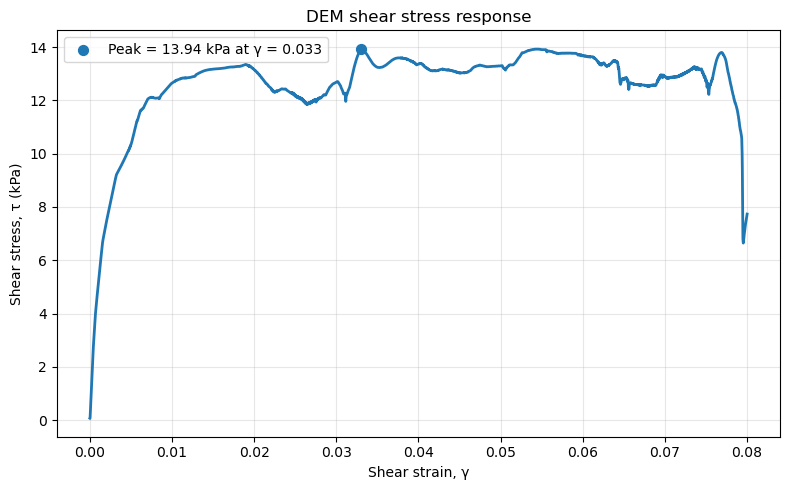

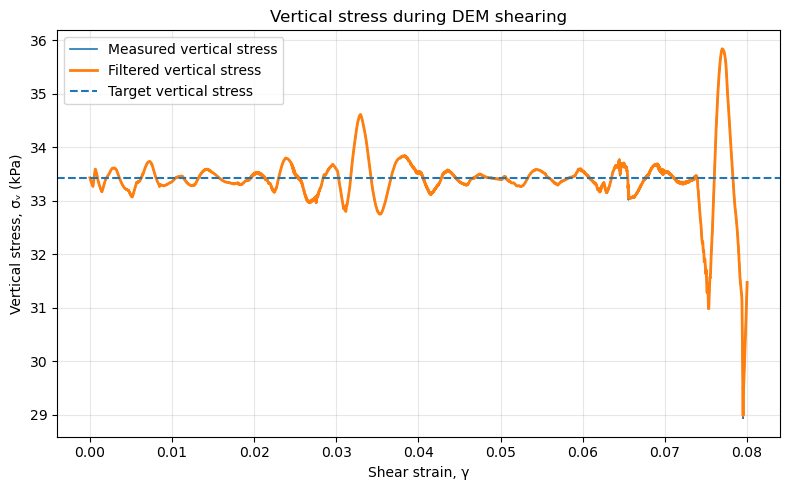

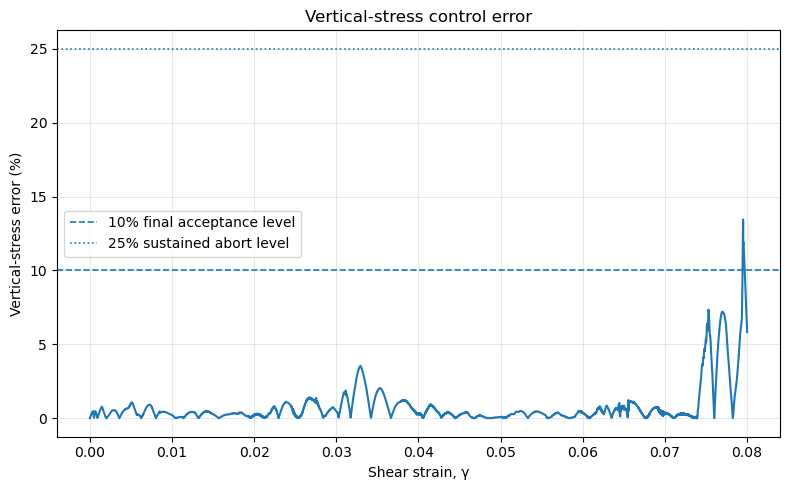

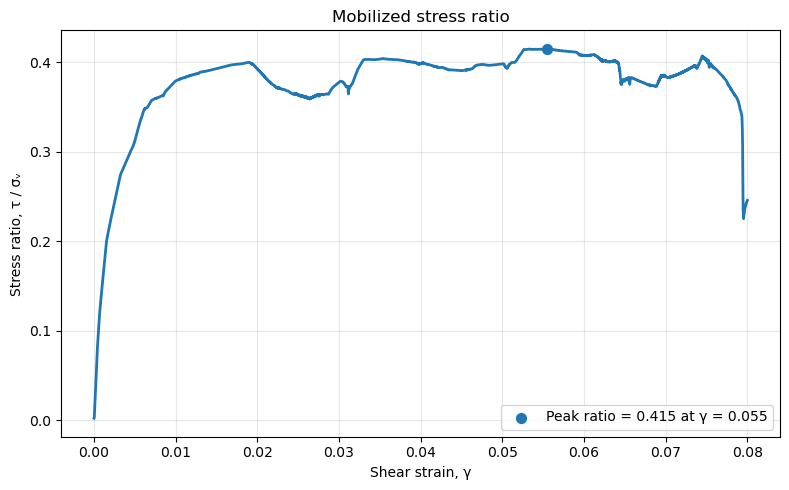

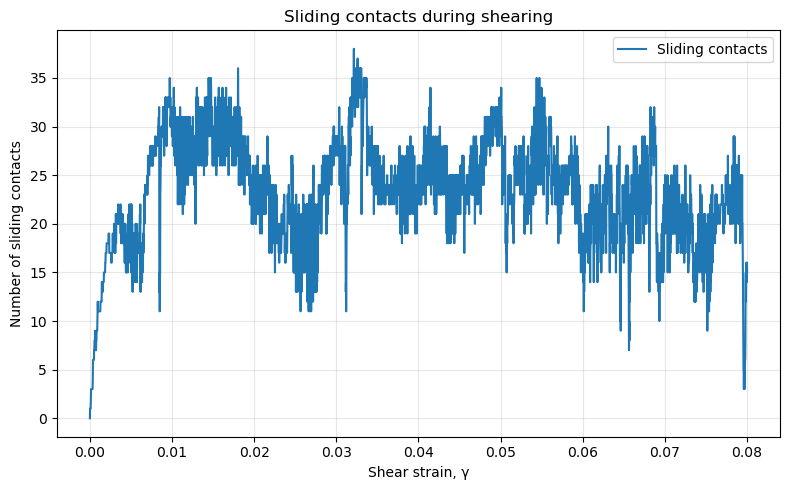

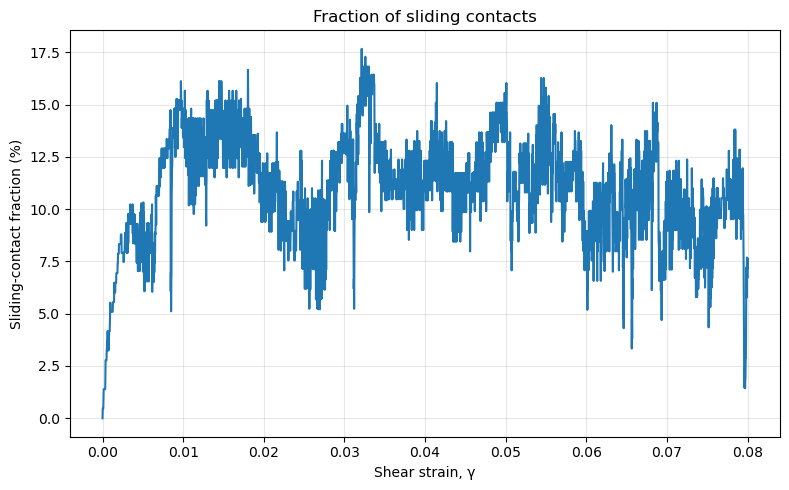

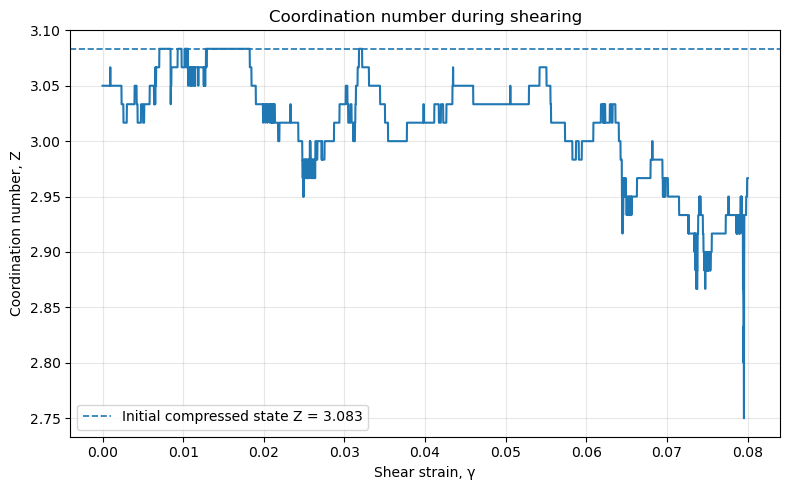

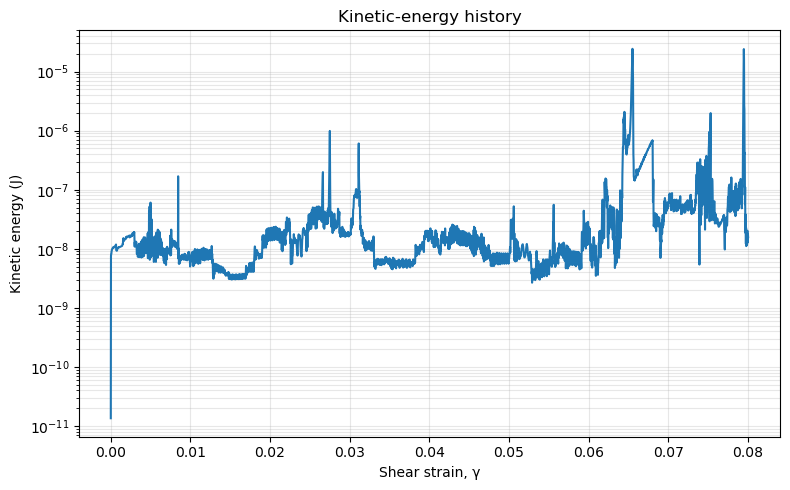

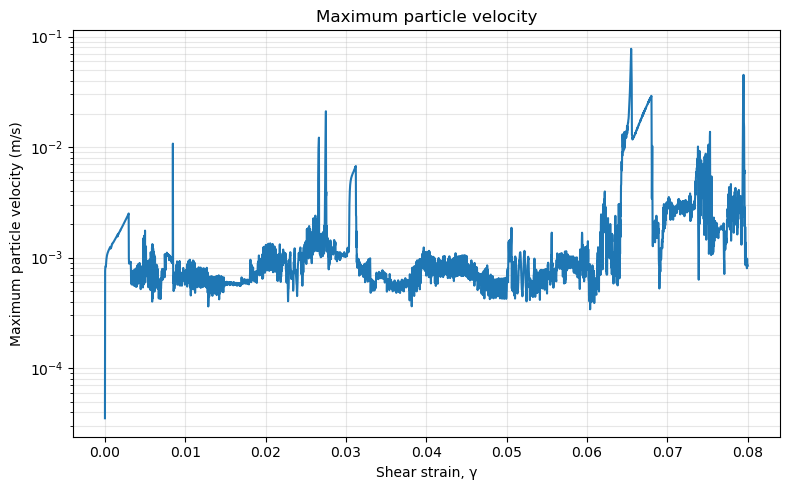

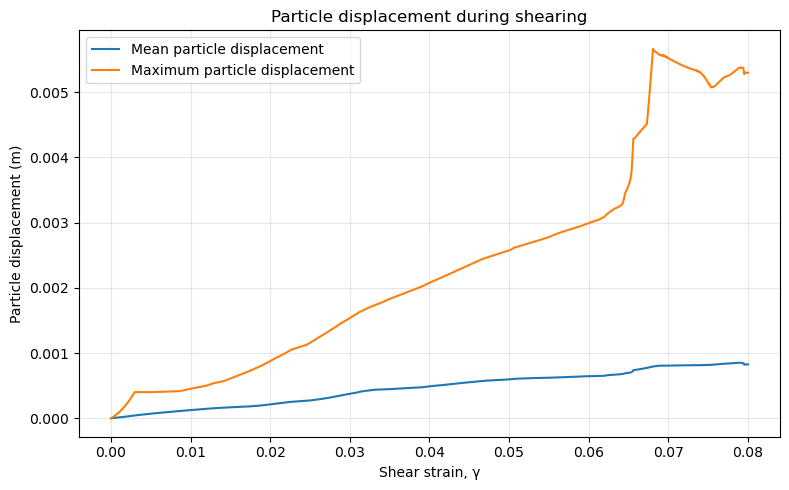

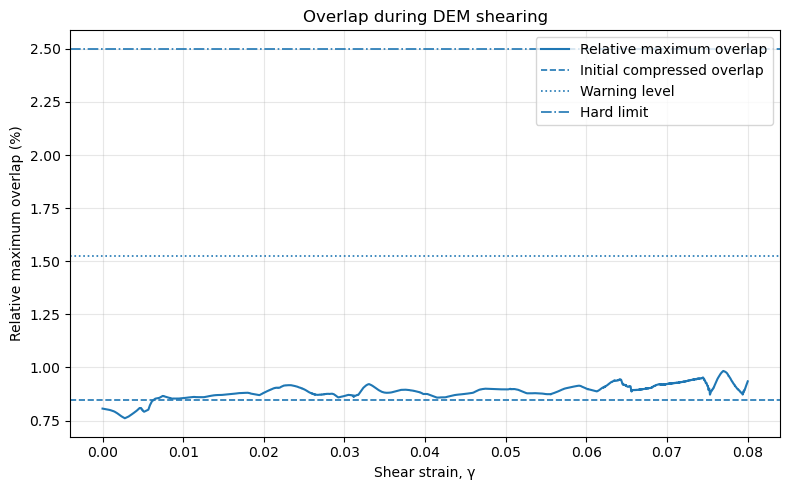

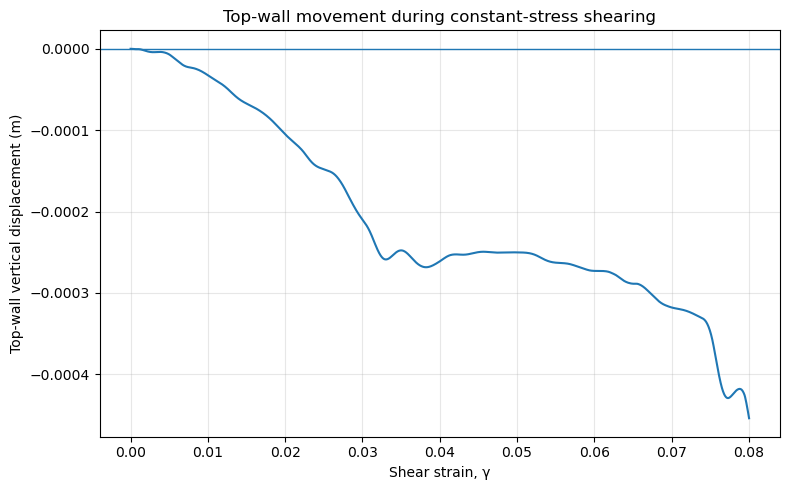

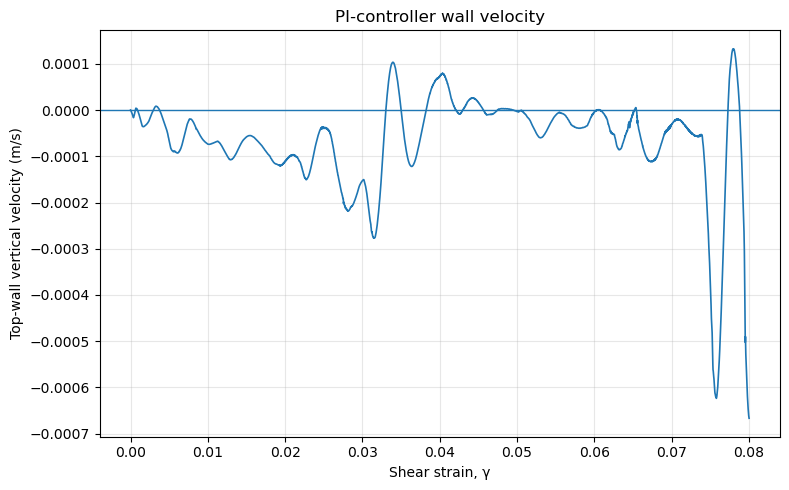

Cell 8 passed if all 13 plots were produced without an error.


In [8]:
# ============================================================
# Cell 8 - Shear-test diagnostic plots
# ============================================================

if len(history_shear_strain) == 0:

    raise RuntimeError(
        "No shear history is available for plotting."
    )


# ------------------------------------------------------------
# Plot 1: Shear stress versus shear strain
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_shear_strain,
    history_shear_stress / 1000.0,
    linewidth=2.0,
)

plt.scatter(
    peak_shear_strain,
    peak_shear_stress / 1000.0,
    s=50,
    zorder=3,
    label=(
        f"Peak = {peak_shear_stress / 1000.0:.2f} kPa "
        f"at γ = {peak_shear_strain:.3f}"
    ),
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Shear stress, τ (kPa)")
plt.title("DEM shear stress response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 2: Vertical stress control
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_shear_strain,
    history_vertical_stress / 1000.0,
    linewidth=1.2,
    label="Measured vertical stress",
)

plt.plot(
    history_shear_strain,
    history_filtered_vertical_stress / 1000.0,
    linewidth=2.0,
    label="Filtered vertical stress",
)

plt.axhline(
    shear_target_vertical_stress / 1000.0,
    linestyle="--",
    linewidth=1.5,
    label="Target vertical stress",
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Vertical stress, σᵥ (kPa)")
plt.title("Vertical stress during DEM shearing")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 3: Vertical-stress error
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_shear_strain,
    100.0 * history_vertical_stress_error,
    linewidth=1.5,
)

plt.axhline(
    10.0,
    linestyle="--",
    linewidth=1.2,
    label="10% final acceptance level",
)

plt.axhline(
    25.0,
    linestyle=":",
    linewidth=1.2,
    label="25% sustained abort level",
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Vertical-stress error (%)")
plt.title("Vertical-stress control error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 4: Stress ratio
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_shear_strain,
    history_stress_ratio,
    linewidth=2.0,
)

plt.scatter(
    peak_stress_ratio_strain,
    peak_stress_ratio,
    s=50,
    zorder=3,
    label=(
        f"Peak ratio = {peak_stress_ratio:.3f} "
        f"at γ = {peak_stress_ratio_strain:.3f}"
    ),
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Stress ratio, τ / σᵥ")
plt.title("Mobilized stress ratio")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 5: Sliding contacts
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_shear_strain,
    history_sliding_contacts,
    linewidth=1.5,
    label="Sliding contacts",
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Number of sliding contacts")
plt.title("Sliding contacts during shearing")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 6: Sliding-contact fraction
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_shear_strain,
    100.0 * history_sliding_fraction,
    linewidth=1.5,
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Sliding-contact fraction (%)")
plt.title("Fraction of sliding contacts")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 7: Coordination number
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_shear_strain,
    history_coordination_number,
    linewidth=1.5,
)

plt.axhline(
    initial_reconstructed_coordination,
    linestyle="--",
    linewidth=1.2,
    label=(
        "Initial compressed state "
        f"Z = {initial_reconstructed_coordination:.3f}"
    ),
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Coordination number, Z")
plt.title("Coordination number during shearing")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 8: Kinetic energy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.semilogy(
    history_shear_strain,
    np.maximum(
        history_kinetic_energy,
        1.0e-20,
    ),
    linewidth=1.5,
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Kinetic energy (J)")
plt.title("Kinetic-energy history")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 9: Maximum particle velocity
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.semilogy(
    history_shear_strain,
    np.maximum(
        history_maximum_velocity,
        1.0e-12,
    ),
    linewidth=1.5,
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Maximum particle velocity (m/s)")
plt.title("Maximum particle velocity")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 10: Particle displacement
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_shear_strain,
    history_mean_displacement,
    linewidth=1.5,
    label="Mean particle displacement",
)

plt.plot(
    history_shear_strain,
    history_maximum_displacement,
    linewidth=1.5,
    label="Maximum particle displacement",
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Particle displacement (m)")
plt.title("Particle displacement during shearing")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 11: Relative maximum overlap
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_shear_strain,
    100.0 * history_relative_overlap,
    linewidth=1.5,
    label="Relative maximum overlap",
)

plt.axhline(
    100.0 * initial_reconstructed_relative_overlap,
    linestyle="--",
    linewidth=1.2,
    label="Initial compressed overlap",
)

plt.axhline(
    100.0 * shear_overlap_warning_limit,
    linestyle=":",
    linewidth=1.2,
    label="Warning level",
)

plt.axhline(
    100.0 * shear_hard_overlap_limit,
    linestyle="-.",
    linewidth=1.2,
    label="Hard limit",
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Relative maximum overlap (%)")
plt.title("Overlap during DEM shearing")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 12: Top-wall vertical displacement
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_shear_strain,
    history_top_wall_vertical_displacement,
    linewidth=1.5,
)

plt.axhline(
    0.0,
    linewidth=1.0,
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Top-wall vertical displacement (m)")
plt.title("Top-wall movement during constant-stress shearing")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 13: Top-wall vertical velocity
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_shear_strain,
    history_top_wall_vertical_velocity,
    linewidth=1.2,
)

plt.axhline(
    0.0,
    linewidth=1.0,
)

plt.xlabel("Shear strain, γ")
plt.ylabel("Top-wall vertical velocity (m/s)")
plt.title("PI-controller wall velocity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(
    "Cell 8 passed if all 13 plots were produced "
    "without an error."
)

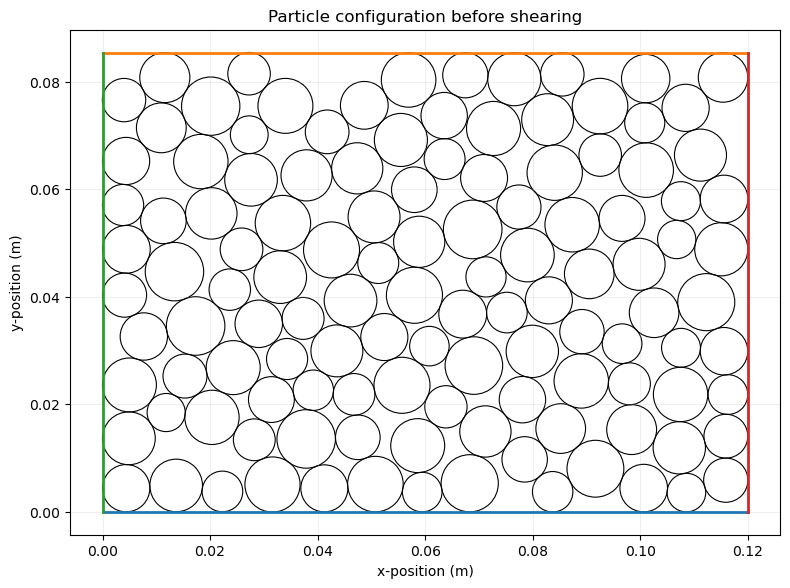

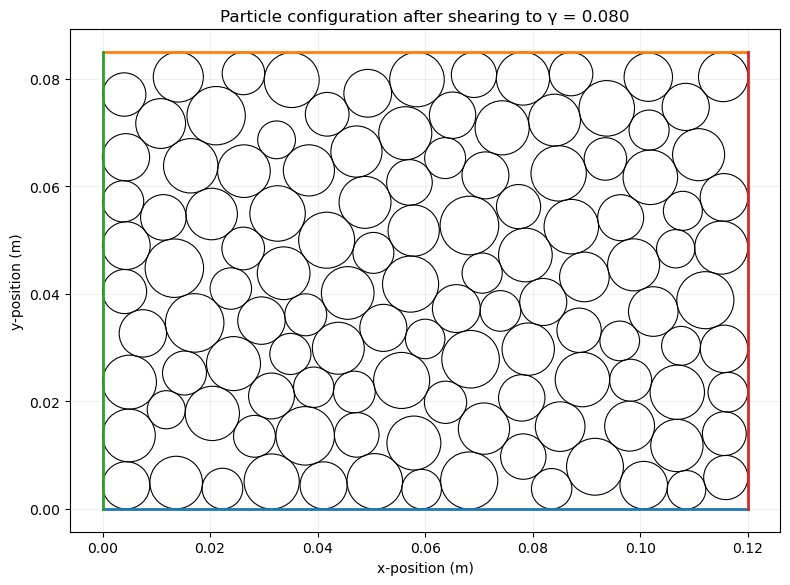

Cell 9 passed if both particle-configuration plots were produced without an error.


In [9]:
# ============================================================
# Cell 9 - Particle configurations before and after shearing
# ============================================================

def plot_particle_configuration(
    particle_positions,
    particle_radii,
    left_wall,
    right_wall,
    bottom_wall,
    top_wall,
    title,
):
    """
    Plot all circular particles and the specimen boundaries.
    """

    figure, axis = plt.subplots(
        figsize=(8, 7)
    )

    for particle_index in range(
        len(particle_radii)
    ):

        particle_circle = plt.Circle(
            (
                particle_positions[
                    particle_index,
                    0,
                ],
                particle_positions[
                    particle_index,
                    1,
                ],
            ),
            particle_radii[
                particle_index
            ],
            fill=False,
            linewidth=0.8,
        )

        axis.add_patch(
            particle_circle
        )


    # --------------------------------------------------------
    # Plot specimen walls
    # --------------------------------------------------------

    axis.plot(
        [left_wall, right_wall],
        [bottom_wall, bottom_wall],
        linewidth=2.0,
    )

    axis.plot(
        [left_wall, right_wall],
        [top_wall, top_wall],
        linewidth=2.0,
    )

    axis.plot(
        [left_wall, left_wall],
        [bottom_wall, top_wall],
        linewidth=2.0,
    )

    axis.plot(
        [right_wall, right_wall],
        [bottom_wall, top_wall],
        linewidth=2.0,
    )


    # --------------------------------------------------------
    # Plot limits and formatting
    # --------------------------------------------------------

    horizontal_margin = (
        0.05 * box_width
    )

    vertical_margin = (
        0.05
        * (
            top_wall
            - bottom_wall
        )
    )

    axis.set_xlim(
        left_wall
        - horizontal_margin,
        right_wall
        + horizontal_margin,
    )

    axis.set_ylim(
        bottom_wall
        - vertical_margin,
        top_wall
        + vertical_margin,
    )

    axis.set_aspect(
        "equal"
    )

    axis.set_xlabel(
        "x-position (m)"
    )

    axis.set_ylabel(
        "y-position (m)"
    )

    axis.set_title(
        title
    )

    axis.grid(
        True,
        alpha=0.2,
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Configuration before shearing
# ------------------------------------------------------------

plot_particle_configuration(
    particle_positions=(
        shear_reference_positions
    ),
    particle_radii=radii,
    left_wall=left_wall_position,
    right_wall=right_wall_position,
    bottom_wall=bottom_wall_position,
    top_wall=(
        shear_reference_top_wall_position
    ),
    title=(
        "Particle configuration before shearing"
    ),
)


# ------------------------------------------------------------
# Configuration after shearing
# ------------------------------------------------------------

plot_particle_configuration(
    particle_positions=positions,
    particle_radii=radii,
    left_wall=left_wall_position,
    right_wall=right_wall_position,
    bottom_wall=bottom_wall_position,
    top_wall=top_wall_position,
    title=(
        "Particle configuration after shearing "
        f"to γ = {final_shear_strain:.3f}"
    ),
)


print(
    "Cell 9 passed if both particle-configuration "
    "plots were produced without an error."
)